In [5]:
%autosave 60

Autosaving every 60 seconds


In [6]:
import numpy as np
import pandas as pd

In [7]:
from tqdm import tqdm
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [8]:
import matplotlib.pyplot as plt

In [9]:
from sklearn import set_config
set_config(transform_output="pandas")

In [10]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# ML практика!

# 1) Валидация моделей
- выборки out of time / out of sample
- adversarial validation разделение выборки
- cross validation / time series cross validation
- создание кастомной метрики качества в sklearn


https://scikit-learn.org/stable/modules/cross_validation.html

In [63]:
path_files = 'drive/MyDrive/ШАД 2025/'
train = pd.read_csv(path_files + 'train_2.csv')

train.drop(['_id', 'last_dt', 'name'], axis=1, inplace=True)

In [64]:
train.head(1)

,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,avg_reviews,total_host,target
0,Sarina,Queens,Neponsit,40.57215,-73.85822,Entire home/apt,350,2,5,2.88,1,334


In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    train.drop('target', axis=1),
    train['target'],
    test_size=0.33,
    random_state=42,
    stratify=train['target']
)

# X_train - train
# X_test - out of sample

In [66]:
sum(
    np.array(sorted(y_train))[: 24204] - np.array(sorted(sorted(y_test) * int(y_train.shape[0] / y_test.shape[0])))
)
# 140_324 - без stratify
# 89_723 - с stratify

# TODO: колмогоров-смирнов тест для оценки
# https://github.com/MaximShalankin/maxim_ml/blob/main/theory_and_practice/data_quality/notebooks/001_data_quality.ipynb

np.int64(-89723)

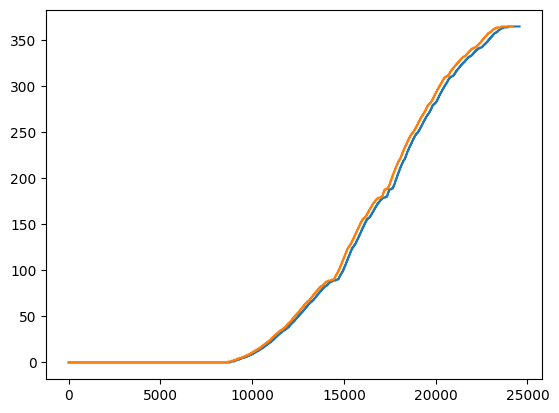

In [67]:
plt.plot(sorted(y_train))
plt.plot(sorted(sorted(y_test) * int(y_train.shape[0] / y_test.shape[0])))

plt.show()

In [68]:
X_train.head(1)

,host_name,location_cluster,location,lat,lon,type_house,sum,min_days,amt_reviews,avg_reviews,total_host
15399,Katie Graham,Brooklyn,Clinton Hill,40.69454,-73.96198,Private room,90,30,47,0.91,6


In [69]:
cat_columns = ['host_name', 'location_cluster', 'location', 'type_house',]

In [70]:
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', oe, cat_columns)
    ], remainder='passthrough'
)

In [71]:
X_train = preprocessor.fit_transform(X_train)

In [72]:
X_test = preprocessor.transform(X_test)

### adversarial validation разделение выборки

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

In [74]:
def adversarial_validation(X_train, X_test, n_folds=5, random_state=42):
    """
    Функция для проведения adversarial validation между тренировочным и тестовым набором данных.

    Параметры:
    X_train - тренировочный набор данных (pandas DataFrame или Series)
    X_test - тестовый набор данных (pandas DataFrame или Series)
    n_folds - количество фолдов для кросс-валидации
    random_state - фиксированное значение для воспроизводимости результатов

    Возвращает:
    mean_auc - среднее значение ROC AUC
    feature_importance - важность признаков
    """

    # Проверяем типы входных данных и преобразуем Series в DataFrame при необходимости
    if isinstance(X_train, pd.Series):
        X_train = X_train.to_frame()

    if isinstance(X_test, pd.Series):
        X_test = X_test.to_frame()

    # Проверяем, что входные данные являются pandas DataFrame
    if not isinstance(X_train, pd.DataFrame) or not isinstance(X_test, pd.DataFrame):
        raise TypeError("X_train и X_test должны быть pandas DataFrame или Series")

    # Проверяем, что все колонки имеют имена
    if any(not isinstance(col, str) for col in X_train.columns) or any(not isinstance(col, str) for col in X_test.columns):
        raise ValueError("Все колонки в X_train и X_test должны иметь строковые имена")

    # Проверяем, что наборы данных имеют одинаковые колонки
    if set(X_train.columns) != set(X_test.columns):
        raise ValueError("Колонки в тренировочном и тестовом наборах должны совпадать")

    # Создаем новый целевой признак: 0 для тренировочных данных, 1 для тестовых
    X_train_labeled = X_train.copy()
    X_test_labeled = X_test.copy()

    X_train_labeled['is_test'] = 0
    X_test_labeled['is_test'] = 1

    # Объединяем данные в один датасет
    combined_data = pd.concat([X_train_labeled, X_test_labeled], axis=0)

    # Перемешиваем данные
    combined_data = combined_data.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Выделяем признаки и целевую переменную
    X = combined_data.drop('is_test', axis=1)
    y = combined_data['is_test']

    # Проверяем, что все колонки в X содержат числовые данные
    non_numeric_cols = [col for col in X.columns if not np.issubdtype(X[col].dtype, np.number)]
    if non_numeric_cols:
        raise ValueError(f"Следующие колонки содержат нечисловые данные: {non_numeric_cols}. "
                         f"Преобразуйте их в числовой формат перед использованием.")

    # Инициализируем модель XGBoost
    model = XGBClassifier(
        max_depth=3,
        learning_rate=0.1,
        n_estimators=100,
        objective='binary:logistic',
        random_state=random_state
    )

    # Инициализируем кросс-валидацию
    cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    # Списки для хранения результатов
    auc_scores = []
    y_true_all = []
    y_pred_all = []

    # Проводим кросс-валидацию
    for i, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]

        # Обучаем модель
        model.fit(X_fold_train, y_fold_train)

        # Получаем предсказания вероятностей
        y_pred = model.predict_proba(X_fold_val)[:, 1]

        # Вычисляем ROC AUC
        auc = roc_auc_score(y_fold_val, y_pred)
        auc_scores.append(auc)

        # Сохраняем результаты для построения общей ROC-кривой
        y_true_all.extend(y_fold_val)
        y_pred_all.extend(y_pred)

        print(f"Фолд {i+1}: ROC AUC = {auc:.4f}")

    # Вычисляем среднее значение ROC AUC
    mean_auc = np.mean(auc_scores)
    print(f"\nСреднее значение ROC AUC: {mean_auc:.4f}")

    # Обучаем модель на всех данных для получения важности признаков
    final_model = XGBClassifier(
        max_depth=3,
        learning_rate=0.1,
        n_estimators=100,
        objective='binary:logistic',
        random_state=random_state
    )
    final_model.fit(X, y)

    # Получаем важность признаков
    feature_importance = pd.DataFrame({
        'Признак': X.columns,
        'Важность': final_model.feature_importances_
    }).sort_values('Важность', ascending=False)

    # Строим ROC-кривую
    fpr, tpr, _ = roc_curve(y_true_all, y_pred_all)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, label=f'ROC кривая (AUC = {mean_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривая для Adversarial Validation')
    plt.legend()
    plt.grid(True)

    # Выводим топ-10 важных признаков
    plt.figure(figsize=(12, 6))
    top_features = feature_importance.head(min(10, len(feature_importance)))
    plt.barh(top_features['Признак'], top_features['Важность'])
    plt.xlabel('Важность')
    plt.ylabel('Признак')
    plt.title('Топ-10 признаков по важности')
    plt.gca().invert_yaxis()  # Инвертируем ось Y для отображения самых важных признаков сверху

    return mean_auc, feature_importance

Фолд 1: ROC AUC = 0.6272
Фолд 2: ROC AUC = 0.6265
Фолд 3: ROC AUC = 0.6164
Фолд 4: ROC AUC = 0.6260
Фолд 5: ROC AUC = 0.6166

Среднее значение ROC AUC: 0.6225


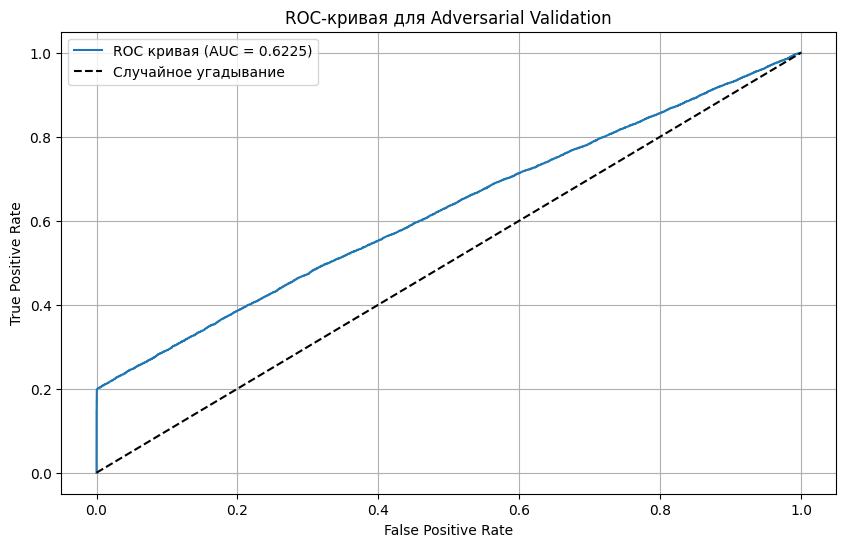

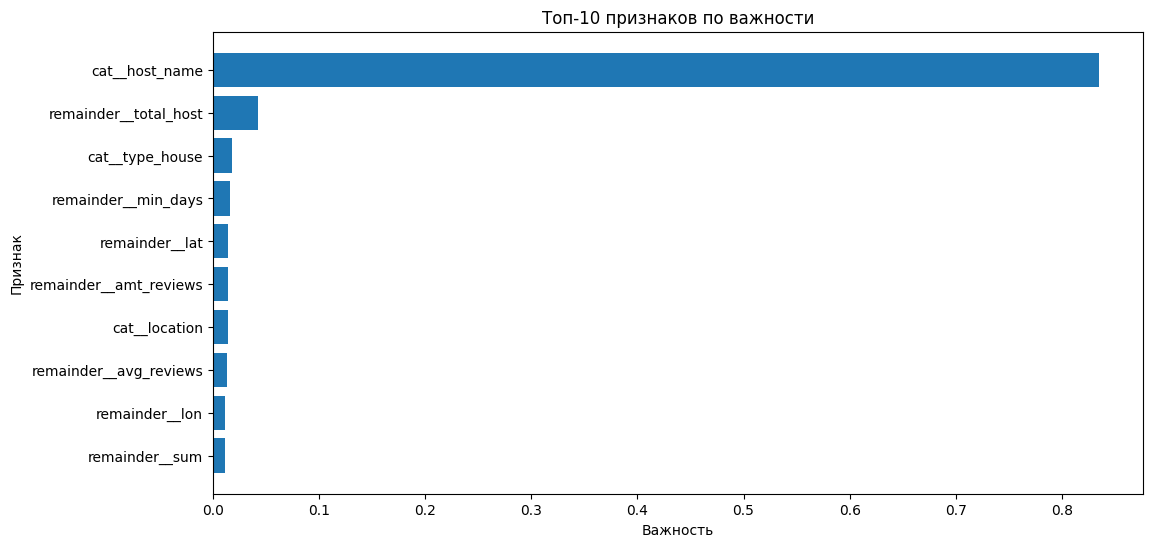

In [75]:
# Проведение adversarial validation
mean_auc, feature_importance = adversarial_validation(X_train, X_test)

In [84]:
(
    len(set(X_train['cat__host_name']).intersection(set(X_test['cat__host_name']))),
    X_train['cat__host_name'].nunique(),
    X_test['cat__host_name'].nunique(),
    train['host_name'].nunique() / train.shape[0]
)

(2555, 7465, 2555, 0.26257805895666875)

In [87]:
np.mean(train['host_name'].value_counts() == 1)
# TODO: те host_name у кого value_counts() == 1 положить в отдельную категорию

np.float64(0.6190674005608059)

Фолд 1: ROC AUC = 0.4389
Фолд 2: ROC AUC = 0.4342
Фолд 3: ROC AUC = 0.4395
Фолд 4: ROC AUC = 0.4381
Фолд 5: ROC AUC = 0.4301

Среднее значение ROC AUC: 0.4362


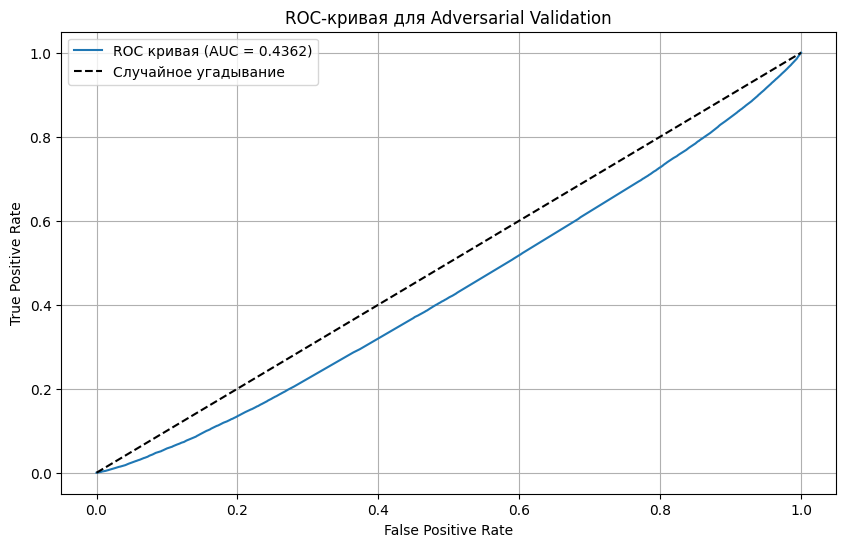

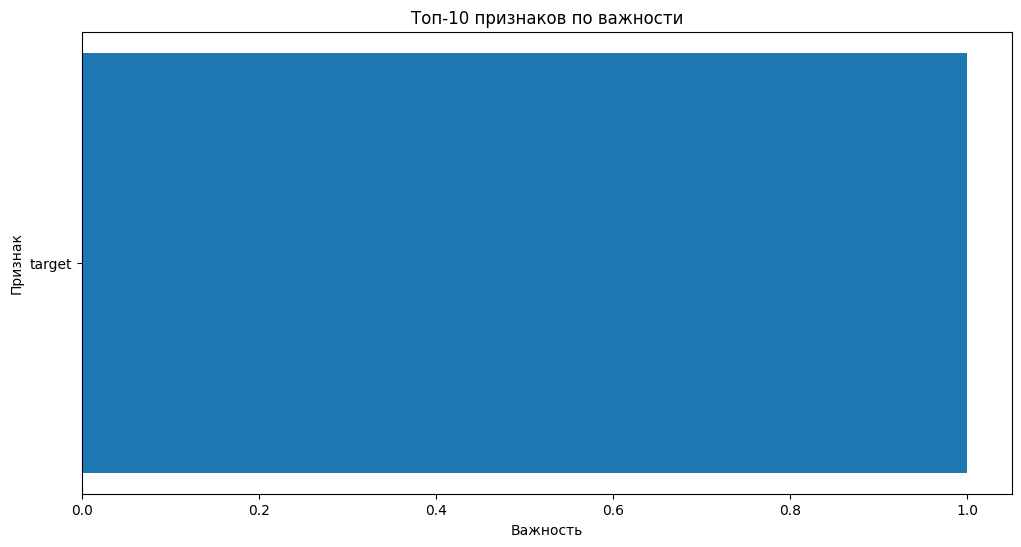

In [88]:
# Проведение adversarial validation для target
mean_auc, feature_importance = adversarial_validation(y_train, y_test)

In [90]:
# NOTE: для соревы достаточно OOS (out of sample выборки)
# Для работы нет. Нужна OOT (out of time выборка)

### out of time

In [133]:
train = pd.read_csv(path_files + 'train_2.csv')

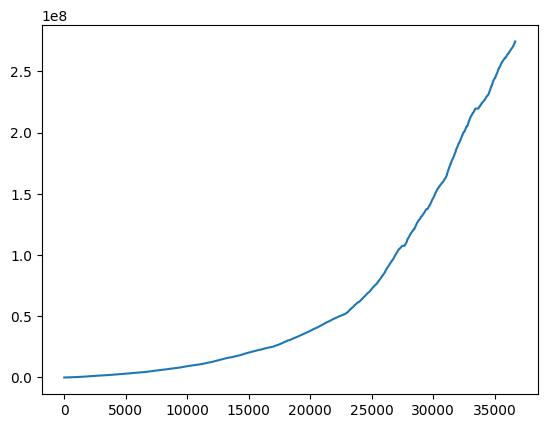

In [134]:
plt.plot(sorted(train['_id']))
plt.show()

In [135]:
np.mean(train['_id'] >= np.quantile(train['_id'], 0.85))

np.float64(0.1500095443265796)

In [136]:
mask_oot = train['_id'] >= np.quantile(train['_id'], 0.85)

In [137]:
train.drop(['_id', 'last_dt', 'name', 'host_name'], axis=1, inplace=True)

In [143]:
cat_columns = ['location_cluster', 'location', 'type_house',]

In [144]:
data_oot = train[mask_oot].reset_index(drop=True).copy()
data_train = train[~mask_oot].reset_index(drop=True).copy()

y_oot = data_oot['target'].copy()

In [145]:
data_oot.shape, data_train.shape

((5501, 11), (31170, 11))

In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    data_train.drop('target', axis=1),
    data_train['target'],
    test_size=0.33,
    random_state=42,
    stratify=data_train['target'],
)

In [147]:
# NOTE: OOS / OOT - две выборки для оценки перформанса модели

# X_test   - oos
# data_oot - oot
# X_train  - train

In [148]:
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', oe, cat_columns)
    ], remainder='passthrough'
)

In [149]:
X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)
data_oot = preprocessor.transform(data_oot)

Фолд 1: ROC AUC = 0.6212
Фолд 2: ROC AUC = 0.6269
Фолд 3: ROC AUC = 0.6165
Фолд 4: ROC AUC = 0.6279
Фолд 5: ROC AUC = 0.6201

Среднее значение ROC AUC: 0.6225


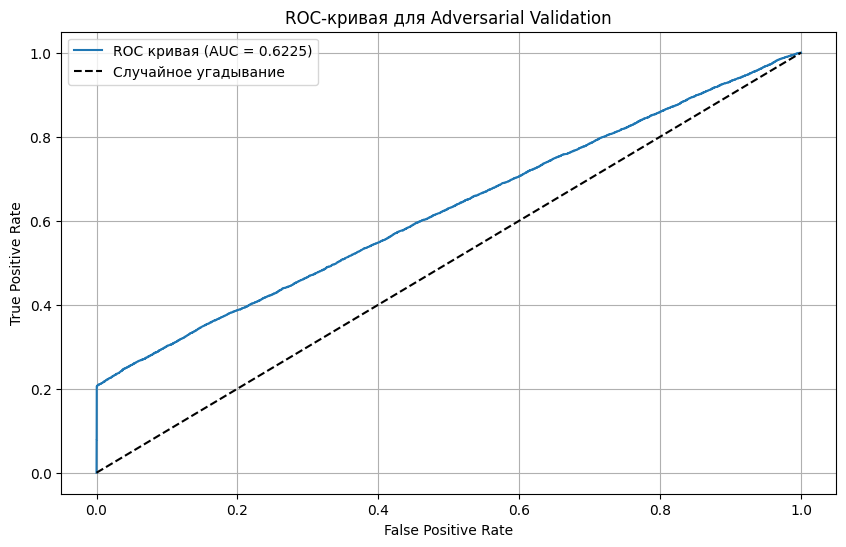

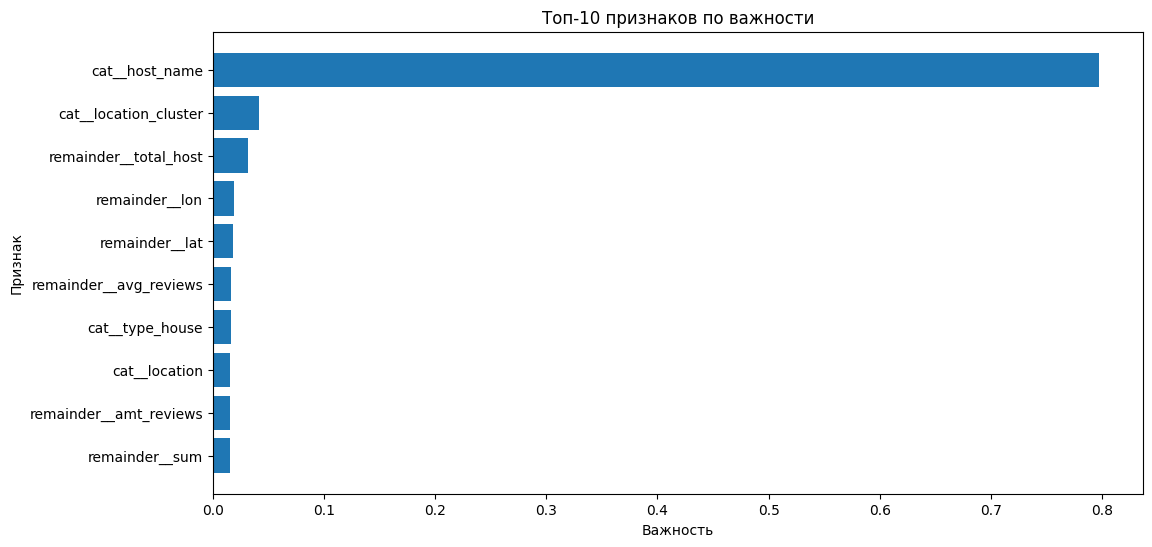

In [109]:
mean_auc, feature_importance = adversarial_validation(X_train, X_test)

Фолд 1: ROC AUC = 0.8868
Фолд 2: ROC AUC = 0.8918
Фолд 3: ROC AUC = 0.8888
Фолд 4: ROC AUC = 0.8914
Фолд 5: ROC AUC = 0.8882

Среднее значение ROC AUC: 0.8894


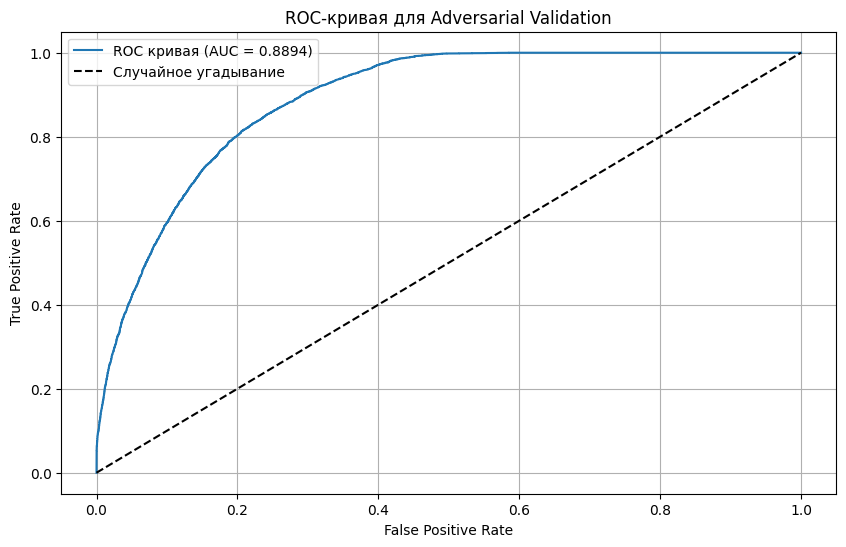

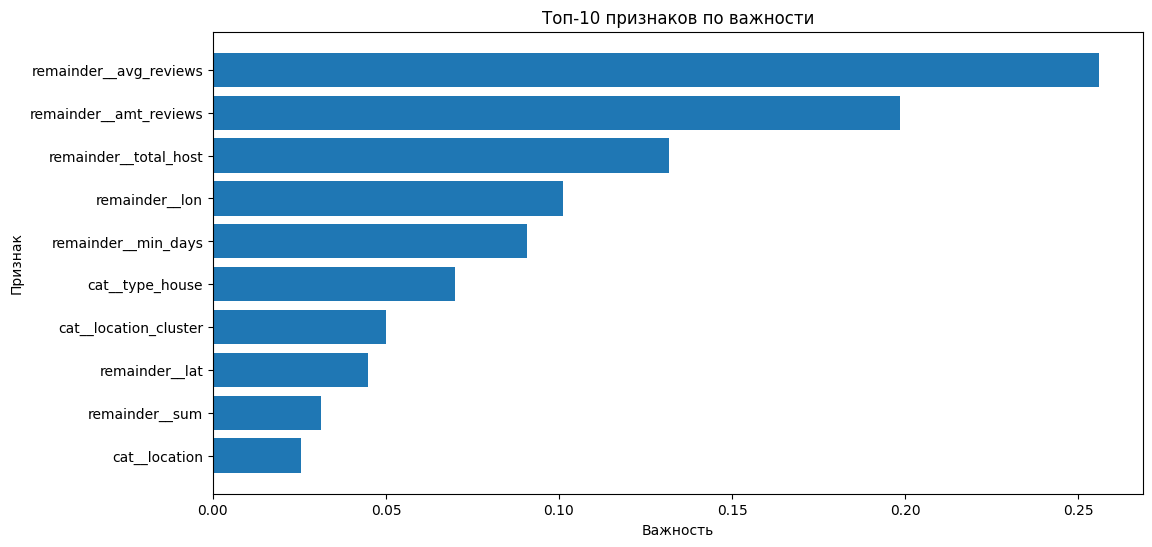

In [150]:
mean_auc, feature_importance = adversarial_validation(X_train, data_oot)

In [112]:
(
    len(set(X_train['cat__host_name']).intersection(set(data_oot['cat__host_name']))),
    X_train['cat__host_name'].nunique(),
    data_oot['cat__host_name'].nunique(),
    train['host_name'].nunique() / train.shape[0]
)

(1083, 6530, 1083, 0.26257805895666875)

### cross validation

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm

In [156]:
import xgboost as xgb

In [153]:
def cross_validation_with_residuals(
    X_train, y_train, X_test, y_test, X_oot=None, y_oot=None,
    model=None, n_folds=5, random_state=42
    ):
    """
    Функция для проведения кросс-валидации с отслеживанием MSE и визуализацией остатков

    Параметры:
    X_train - признаки обучающей выборки (pandas DataFrame)
    y_train - целевая переменная обучающей выборки (pandas Series или numpy array)
    X_test - признаки тестовой выборки (pandas DataFrame)
    y_test - целевая переменная тестовой выборки (pandas Series или numpy array)
    X_oot - признаки out-of-time выборки (pandas DataFrame), опционально
    y_oot - целевая переменная out-of-time выборки (pandas Series или numpy array), опционально
    model - модель машинного обучения (по умолчанию RandomForestRegressor)
    n_folds - количество фолдов для кросс-валидации
    random_state - фиксированное значение для воспроизводимости результатов

    Возвращает:
    cv_results - словарь с результатами кросс-валидации
    final_model - обученная модель на всех тренировочных данных
    """

    # Проверка входных данных
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train должен быть pandas DataFrame")

    if not isinstance(X_test, pd.DataFrame):
        raise TypeError("X_test должен быть pandas DataFrame")

    if X_oot is not None and not isinstance(X_oot, pd.DataFrame):
        raise TypeError("X_oot должен быть pandas DataFrame")

    # Проверка, что все наборы данных имеют одинаковые колонки
    if not set(X_train.columns) == set(X_test.columns):
        raise ValueError("Колонки в X_train и X_test должны совпадать")

    if X_oot is not None and not set(X_train.columns) == set(X_oot.columns):
        raise ValueError("Колонки в X_train и X_oot должны совпадать")

    # Если модель не задана, используем RandomForestRegressor по умолчанию
    if model is None:
        model = RandomForestRegressor(n_estimators=100, random_state=random_state)

    # Инициализируем KFold для кросс-валидации
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    # Словарь для хранения результатов
    cv_results = {
        'train_predictions': np.zeros(len(y_train)),
        'train_actual': y_train,
        'test_predictions': None,
        'test_actual': y_test,
        'oot_predictions': None,
        'oot_actual': y_oot if y_oot is not None else None,
        'fold_mse': [],
        'train_mse': 0,
        'test_mse': 0,
        'oot_mse': 0 if y_oot is not None else None
    }

    # Массивы для хранения предсказаний и истинных значений по фолдам
    fold_train_mse = []
    fold_val_mse = []

    print("Начинаем процесс кросс-валидации...")

    # Проходим по всем фолдам
    for fold, (train_idx, val_idx) in enumerate(tqdm(kf.split(X_train), total=n_folds, desc="Фолды")):
        # Разделяем данные на обучающую и валидационную выборки
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx] if isinstance(y_train, pd.Series) else y_train[train_idx], \
                                  y_train.iloc[val_idx] if isinstance(y_train, pd.Series) else y_train[val_idx]

        # Обучаем модель
        model.fit(X_fold_train, y_fold_train)

        # Делаем предсказания на обучающей и валидационной выборках
        y_fold_train_pred = model.predict(X_fold_train)
        y_fold_val_pred = model.predict(X_fold_val)

        # Сохраняем предсказания для этого фолда
        cv_results['train_predictions'][val_idx] = y_fold_val_pred

        # Вычисляем MSE для этого фолда
        train_mse = mean_squared_error(y_fold_train, y_fold_train_pred)
        val_mse = mean_squared_error(y_fold_val, y_fold_val_pred)

        fold_train_mse.append(train_mse)
        fold_val_mse.append(val_mse)
        cv_results['fold_mse'].append(val_mse)

        print(f"Фолд {fold+1}/{n_folds}:")
        print(f"  MSE на обучающей выборке: {train_mse:.4f}")
        print(f"  MSE на валидационной выборке: {val_mse:.4f}")

    # Вычисляем средние значения MSE
    cv_results['train_mse'] = np.mean(fold_train_mse)
    cv_results['val_mse'] = np.mean(fold_val_mse)

    print(f"\nСредняя MSE на обучающей выборке: {cv_results['train_mse']:.4f}")
    print(f"Средняя MSE на валидационной выборке: {cv_results['val_mse']:.4f}")

    # Обучаем финальную модель на всех тренировочных данных
    print("\nОбучаем финальную модель на всех тренировочных данных...")
    final_model = model.fit(X_train, y_train)

    # Делаем предсказания на тестовой выборке
    cv_results['test_predictions'] = final_model.predict(X_test)

    # Вычисляем MSE на тестовой выборке
    cv_results['test_mse'] = mean_squared_error(y_test, cv_results['test_predictions'])
    print(f"MSE на тестовой выборке: {cv_results['test_mse']:.4f}")

    # Если есть OOT данные, делаем предсказания на них
    if X_oot is not None and y_oot is not None:
        cv_results['oot_predictions'] = final_model.predict(X_oot)
        cv_results['oot_mse'] = mean_squared_error(y_oot, cv_results['oot_predictions'])
        print(f"MSE на OOT выборке: {cv_results['oot_mse']:.4f}")

    # Визуализация результатов
    visualize_cv_results(cv_results, n_folds)

    # Визуализация остатков
    visualize_residuals(y_test, cv_results['test_predictions'], "Тестовая выборка")

    # Если есть OOT данные, визуализируем остатки для них
    if X_oot is not None and y_oot is not None:
        visualize_residuals(y_oot, cv_results['oot_predictions'], "OOT выборка")

    return cv_results, final_model

def visualize_cv_results(cv_results, n_folds):
    """
    Функция для визуализации результатов кросс-валидации

    Параметры:
    cv_results - словарь с результатами кросс-валидации
    n_folds - количество фолдов
    """
    # Настраиваем стиль графиков
    sns.set(style="whitegrid")

    # 1. График MSE по фолдам
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, n_folds+1), cv_results['fold_mse'], color='skyblue')
    plt.axhline(y=np.mean(cv_results['fold_mse']), color='r', linestyle='-',
               label=f'Среднее: {np.mean(cv_results["fold_mse"]):.4f}')
    plt.title('MSE по фолдам')
    plt.xlabel('Номер фолда')
    plt.ylabel('MSE')
    plt.xticks(range(1, n_folds+1))
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Сравнение предсказаний и реальных значений на тренировочных данных
    plt.figure(figsize=(10, 6))
    plt.scatter(cv_results['train_actual'], cv_results['train_predictions'], alpha=0.5)
    min_val = min(min(cv_results['train_actual']), min(cv_results['train_predictions']))
    max_val = max(max(cv_results['train_actual']), max(cv_results['train_predictions']))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.title('Предсказания vs Реальные значения (Тренировочные данные)')
    plt.xlabel('Реальные значения')
    plt.ylabel('Предсказания')
    plt.grid(True)
    plt.show()

    # 3. Сравнение предсказаний и реальных значений на тестовых данных
    plt.figure(figsize=(10, 6))
    plt.scatter(cv_results['test_actual'], cv_results['test_predictions'], alpha=0.5)
    min_val = min(min(cv_results['test_actual']), min(cv_results['test_predictions']))
    max_val = max(max(cv_results['test_actual']), max(cv_results['test_predictions']))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.title('Предсказания vs Реальные значения (Тестовые данные)')
    plt.xlabel('Реальные значения')
    plt.ylabel('Предсказания')
    plt.grid(True)
    plt.show()

    # 4. Если есть OOT данные, визуализируем их
    if cv_results['oot_predictions'] is not None:
        plt.figure(figsize=(10, 6))
        plt.scatter(cv_results['oot_actual'], cv_results['oot_predictions'], alpha=0.5)
        min_val = min(min(cv_results['oot_actual']), min(cv_results['oot_predictions']))
        max_val = max(max(cv_results['oot_actual']), max(cv_results['oot_predictions']))
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')
        plt.title('Предсказания vs Реальные значения (OOT данные)')
        plt.xlabel('Реальные значения')
        plt.ylabel('Предсказания')
        plt.grid(True)
        plt.show()

    # 5. Сравнение MSE на разных наборах данных
    plt.figure(figsize=(10, 6))

    # Собираем метрики для всех наборов данных
    datasets = ['Кросс-валидация', 'Тест']
    mse_values = [cv_results['val_mse'], cv_results['test_mse']]

    if cv_results['oot_mse'] is not None:
        datasets.append('OOT')
        mse_values.append(cv_results['oot_mse'])

    plt.bar(datasets, mse_values, color='skyblue')
    plt.title('Сравнение MSE на разных наборах данных')
    plt.ylabel('MSE')
    plt.grid(True)

    # Добавляем значения MSE над столбцами
    for i, v in enumerate(mse_values):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center')

    plt.show()

In [154]:
def visualize_residuals(y_true, y_pred, dataset_name=""):
    """
    Функция для визуализации остатков регрессионной модели

    Параметры:
    y_true - истинные значения целевой переменной
    y_pred - предсказанные значения
    dataset_name - название набора данных для заголовков графиков
    """
    # Вычисляем остатки
    residuals = y_true - y_pred

    # Создаем фигуру с подграфиками
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Анализ остатков ({dataset_name})', fontsize=16)

    # 1. График остатков относительно предсказанных значений
    axes[0, 0].scatter(y_pred, residuals, alpha=0.5)
    axes[0, 0].axhline(y=0, color='r', linestyle='-')
    axes[0, 0].set_title('Остатки vs Предсказанные значения')
    axes[0, 0].set_xlabel('Предсказанные значения')
    axes[0, 0].set_ylabel('Остатки')
    axes[0, 0].grid(True)

    # 2. Гистограмма остатков
    axes[0, 1].hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 1].set_title('Гистограмма остатков')
    axes[0, 1].set_xlabel('Остатки')
    axes[0, 1].set_ylabel('Частота')
    axes[0, 1].grid(True)

    # 3. QQ-график для проверки нормальности остатков
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('QQ-график остатков')
    axes[1, 0].grid(True)

    # 4. Предсказанные vs Истинные значения
    axes[1, 1].scatter(y_true, y_pred, alpha=0.5)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--')
    axes[1, 1].set_title('Предсказанные vs Истинные значения')
    axes[1, 1].set_xlabel('Истинные значения')
    axes[1, 1].set_ylabel('Предсказанные значения')
    axes[1, 1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Оставляем место для общего заголовка
    plt.show()

In [157]:
# Создаем модель (можно заменить на любую другую регрессионную модель)
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

Начинаем процесс кросс-валидации...


Фолды:  40%|████      | 2/5 [00:00<00:00,  5.01it/s]

Фолд 1/5:
  MSE на обучающей выборке: 10160.7080
  MSE на валидационной выборке: 11049.5781
Фолд 2/5:
  MSE на обучающей выборке: 10252.6387
  MSE на валидационной выборке: 10699.6084


Фолды:  60%|██████    | 3/5 [00:00<00:00,  5.07it/s]

Фолд 3/5:
  MSE на обучающей выборке: 10212.2334
  MSE на валидационной выборке: 10876.9629


Фолды:  80%|████████  | 4/5 [00:00<00:00,  4.99it/s]

Фолд 4/5:
  MSE на обучающей выборке: 10229.0020
  MSE на валидационной выборке: 10865.3193


Фолды: 100%|██████████| 5/5 [00:01<00:00,  4.88it/s]

Фолд 5/5:
  MSE на обучающей выборке: 10302.1963
  MSE на валидационной выборке: 10402.1660

Средняя MSE на обучающей выборке: 10231.3557
Средняя MSE на валидационной выборке: 10778.7270

Обучаем финальную модель на всех тренировочных данных...


MSE на тестовой выборке: 10793.4707
MSE на OOT выборке: 15703.3730


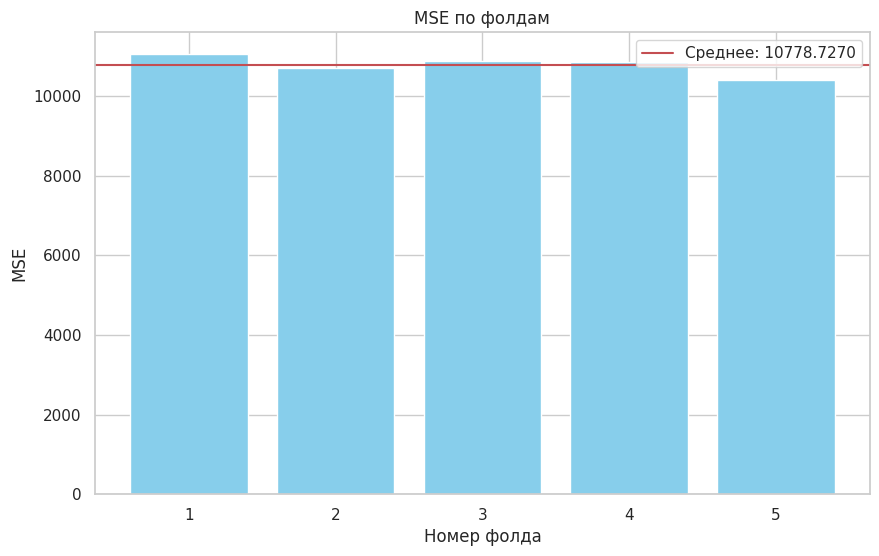

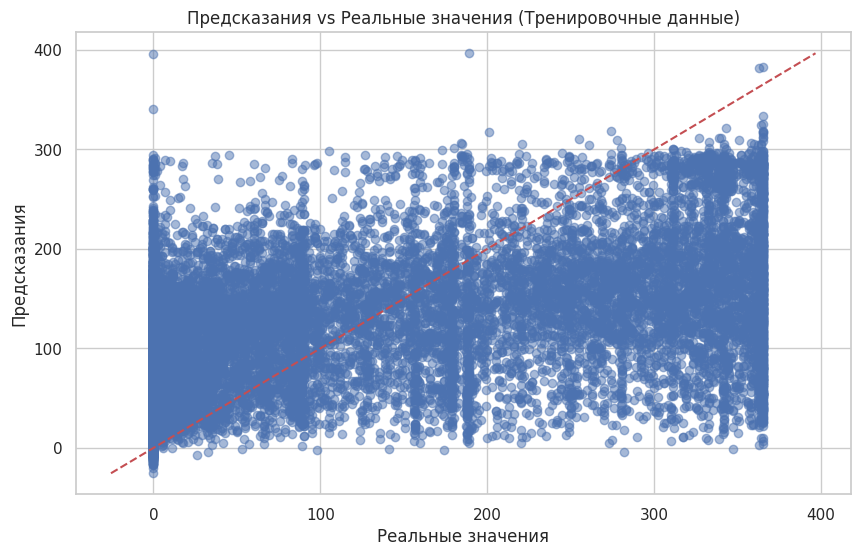

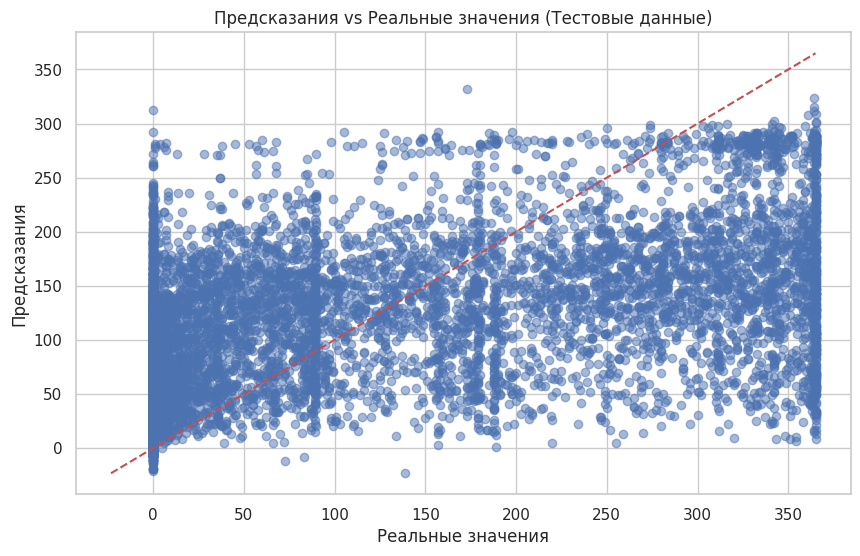

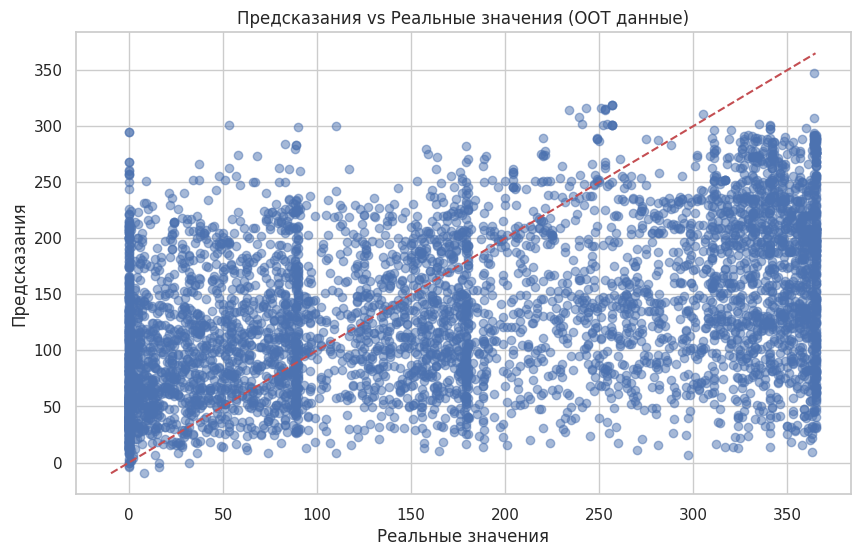

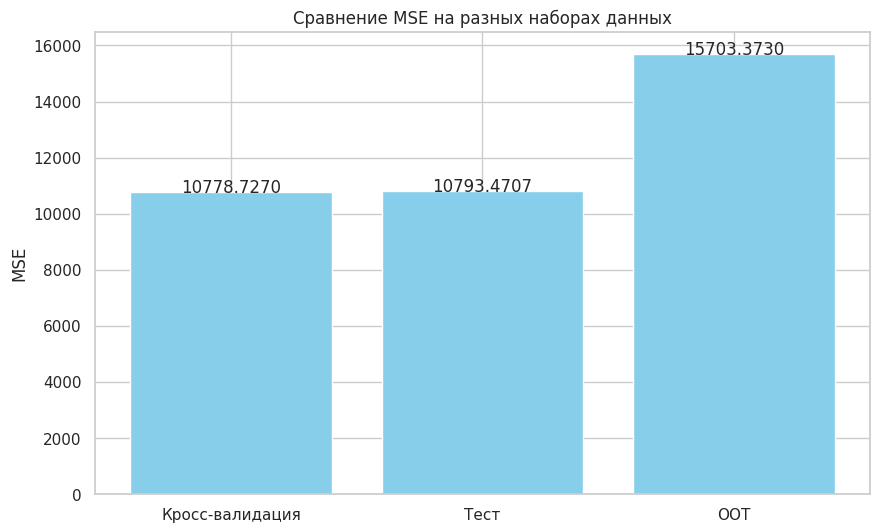

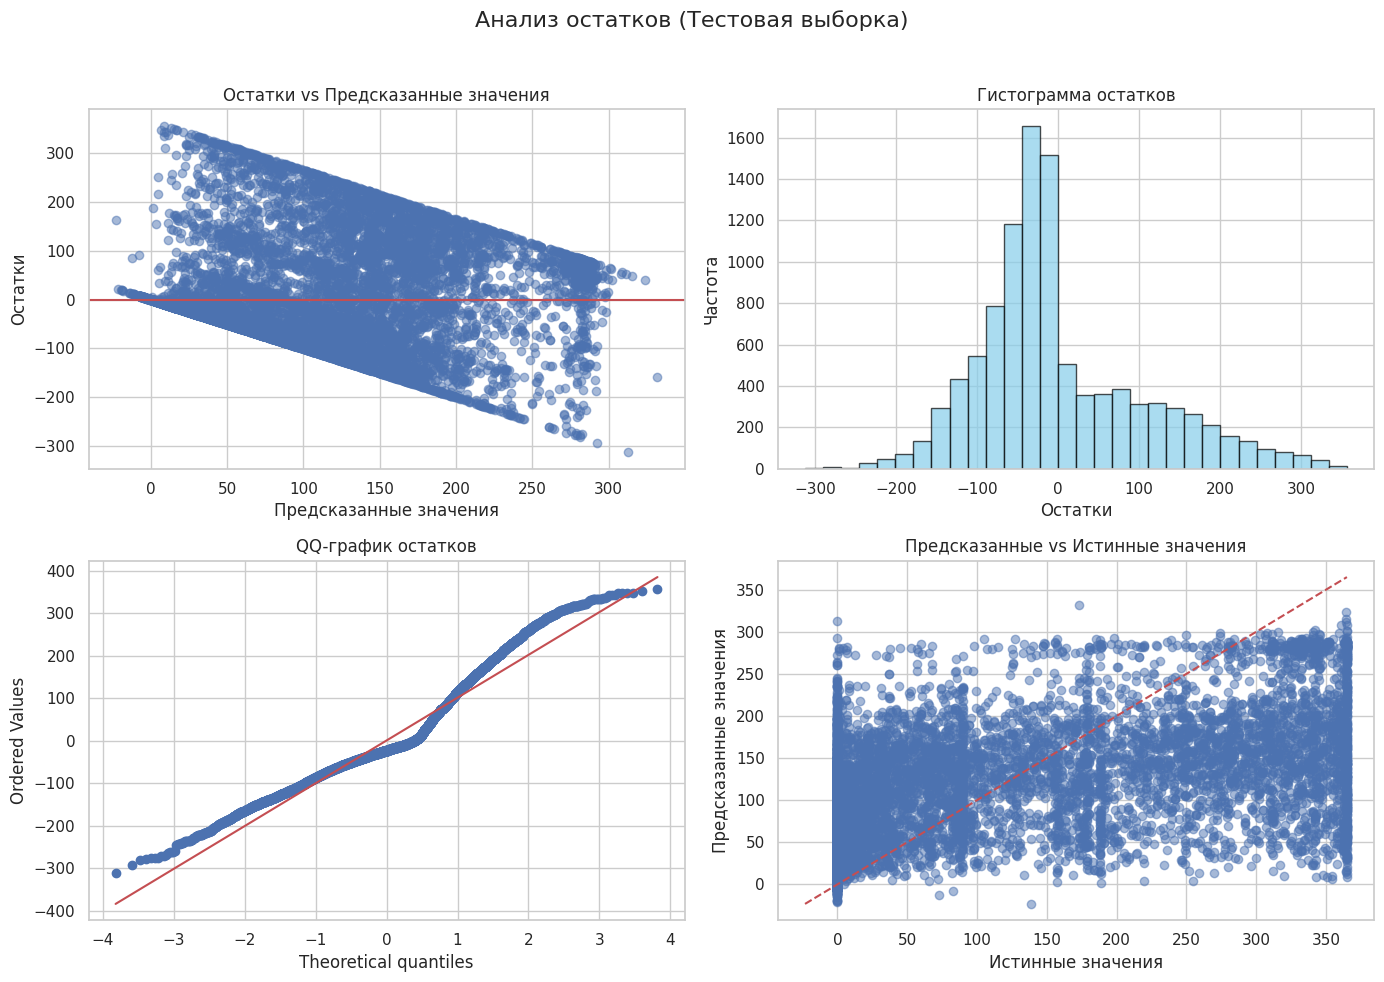

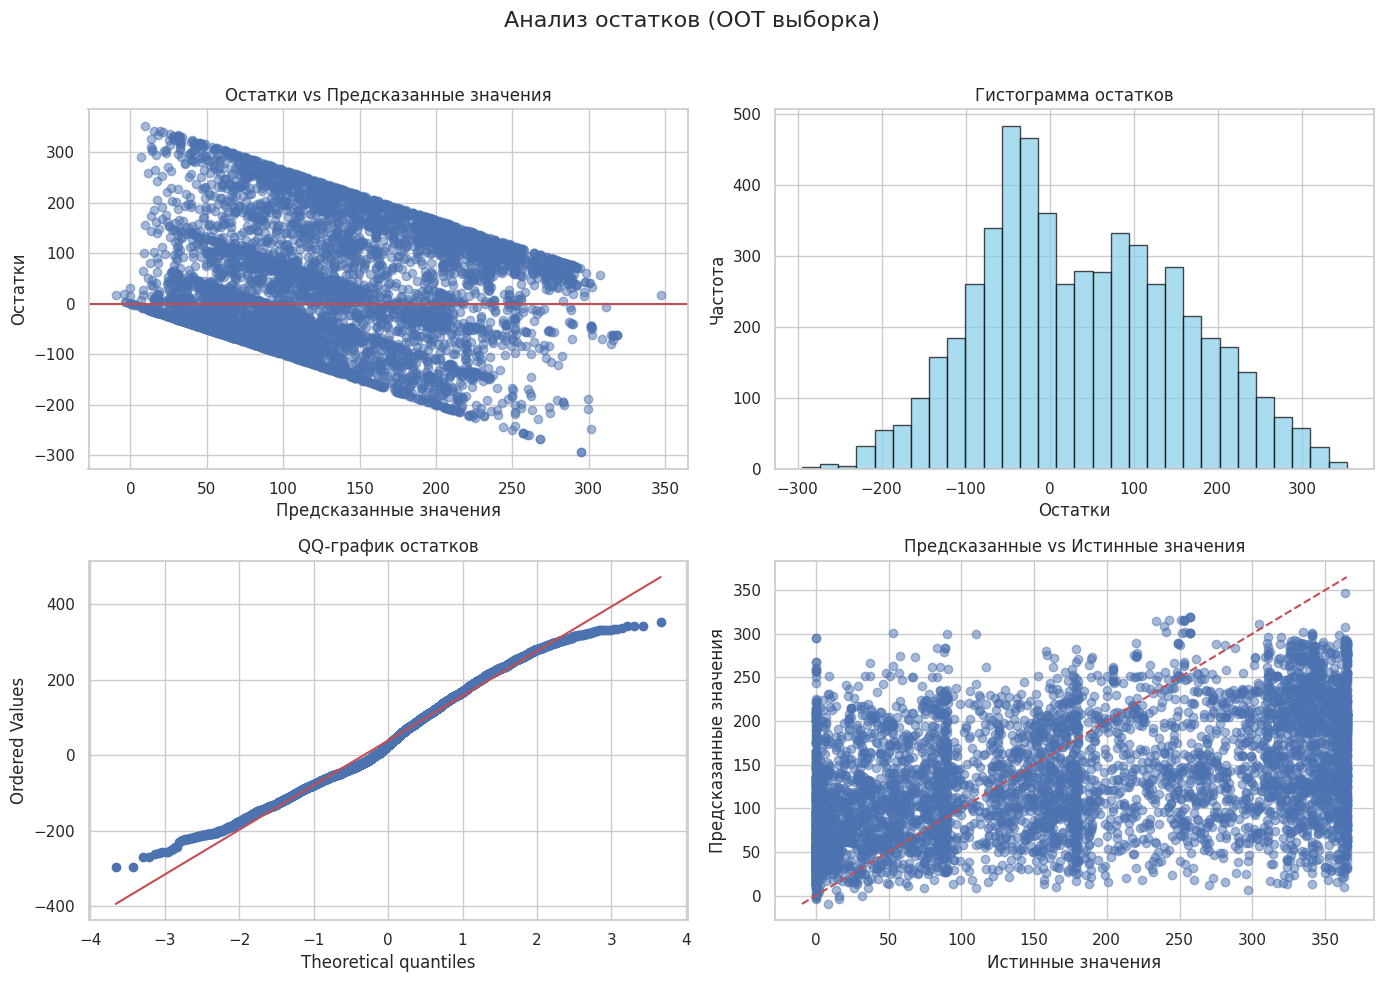

In [159]:
cv_results, final_model = cross_validation_with_residuals(
    X_train, y_train,
    X_test, y_test,
    data_oot, y_oot,
    model=model,
    n_folds=5
)

### time series cross validation

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from tqdm import tqdm

In [201]:
path_files = 'drive/MyDrive/ШАД 2025/'
train = pd.read_csv(path_files + 'train_2.csv')

In [183]:
# train[['_id', 'last_dt']]
# TODO: проверить можно ли сделать умный fillna по _id и last_dt для last_dt
# TODO: last_dt - feature engineering; например diff(2025-03-20, last_dt)
# NOTE: train[['last_dt']]. lambda x: ('2025-03-20' - x) datetime lib

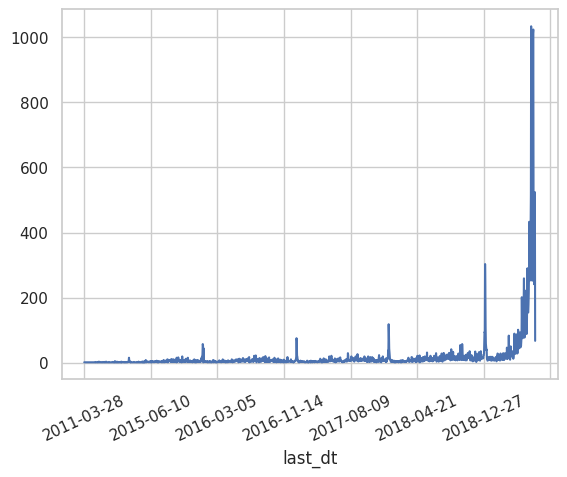

In [186]:
train[~train['last_dt'].isna()]['last_dt'].value_counts().sort_index().plot()
plt.xticks(rotation=25)
plt.show()

In [187]:
train.drop(['last_dt', 'name', 'host_name'], axis=1, inplace=True)
cat_columns = ['location_cluster', 'location', 'type_house']

In [188]:
X_train, X_test, y_train, y_test = train_test_split(
    train.drop('target', axis=1),
    train['target'],
    test_size=0.33,
    random_state=42
)

In [189]:
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', oe, cat_columns)
    ], remainder='passthrough'
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [193]:
def time_series_cross_validation(X_train, y_train, X_test, y_test, X_oot=None, y_oot=None,
                                time_col=None, n_splits=5, gap=0, test_size=None,
                                model=None, random_state=42):
    """
    Функция для проведения кросс-валидации временных рядов с отслеживанием MSE и визуализацией остатков

    Параметры:
    X_train - признаки обучающей выборки (pandas DataFrame)
    y_train - целевая переменная обучающей выборки (pandas Series или numpy array)
    X_test - признаки тестовой выборки (pandas DataFrame)
    y_test - целевая переменная тестовой выборки (pandas Series или numpy array)
    X_oot - признаки out-of-time выборки (pandas DataFrame), опционально
    y_oot - целевая переменная out-of-time выборки (pandas Series или numpy array), опционально
    time_col - название столбца с временной меткой (если None, используется индекс)
    n_splits - количество разбиений для кросс-валидации временных рядов
    gap - количество сэмплов между тренировочным и тестовым наборами
    test_size - размер тестового набора для каждого разбиения (если None, используется по умолчанию)
    model - модель машинного обучения (по умолчанию RandomForestRegressor)
    random_state - фиксированное значение для воспроизводимости результатов

    Возвращает:
    cv_results - словарь с результатами кросс-валидации
    final_model - обученная модель на всех тренировочных данных
    """

    # Проверка входных данных
    if not isinstance(X_train, pd.DataFrame):
        raise TypeError("X_train должен быть pandas DataFrame")

    if not isinstance(X_test, pd.DataFrame):
        raise TypeError("X_test должен быть pandas DataFrame")

    if X_oot is not None and not isinstance(X_oot, pd.DataFrame):
        raise TypeError("X_oot должен быть pandas DataFrame")

    # Проверка, что все наборы данных имеют одинаковые колонки
    train_cols = set(X_train.columns)
    test_cols = set(X_test.columns)

    # Если указан time_col, проверяем его наличие
    if time_col is not None:
        if time_col not in X_train.columns:
            raise ValueError(f"Столбец времени '{time_col}' отсутствует в X_train")
        if time_col not in X_test.columns:
            raise ValueError(f"Столбец времени '{time_col}' отсутствует в X_test")
        if X_oot is not None and time_col not in X_oot.columns:
            raise ValueError(f"Столбец времени '{time_col}' отсутствует в X_oot")

        # Удаляем столбец времени из проверки колонок
        train_cols.remove(time_col)
        test_cols.remove(time_col)

    if train_cols != test_cols:
        raise ValueError("Колонки в X_train и X_test должны совпадать (кроме столбца времени)")

    if X_oot is not None:
        oot_cols = set(X_oot.columns)
        if time_col is not None:
            oot_cols.remove(time_col)
        if train_cols != oot_cols:
            raise ValueError("Колонки в X_train и X_oot должны совпадать (кроме столбца времени)")

    # Если модель не задана, используем RandomForestRegressor по умолчанию
    if model is None:
        model = RandomForestRegressor(n_estimators=100, random_state=random_state)

    # Создаем копии данных для работы
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()

    # Если указан time_col, сортируем данные по времени
    if time_col is not None:
        X_train_copy = X_train_copy.sort_values(by=time_col).reset_index(drop=True)
        y_train = y_train.iloc[X_train_copy.index] if isinstance(y_train, pd.Series) else y_train[X_train_copy.index]

        X_test_copy = X_test_copy.sort_values(by=time_col).reset_index(drop=True)
        y_test = y_test.iloc[X_test_copy.index] if isinstance(y_test, pd.Series) else y_test[X_test_copy.index]

        if X_oot is not None:
            X_oot = X_oot.sort_values(by=time_col).reset_index(drop=True)
            y_oot = y_oot.iloc[X_oot.index] if isinstance(y_oot, pd.Series) else y_oot[X_oot.index]

    # Инициализируем TimeSeriesSplit
    tscv = TimeSeriesSplit(n_splits=n_splits, gap=gap, test_size=test_size)

    # Словарь для хранения результатов
    cv_results = {
        'train_predictions': np.zeros(len(y_train)),
        'train_actual': y_train,
        'test_predictions': None,
        'test_actual': y_test,
        'oot_predictions': None,
        'oot_actual': y_oot if y_oot is not None else None,
        'fold_mse': [],
        'fold_train_indices': [],
        'fold_test_indices': [],
        'fold_timestamps': [],
        'train_mse': 0,
        'test_mse': 0,
        'oot_mse': 0 if y_oot is not None else None
    }

    # Если указан time_col, сохраняем временные метки
    if time_col is not None:
        cv_results['train_timestamps'] = X_train_copy[time_col].values
        cv_results['test_timestamps'] = X_test_copy[time_col].values
        if X_oot is not None:
            cv_results['oot_timestamps'] = X_oot[time_col].values

    # Удаляем столбец времени из данных для обучения, если он указан
    if time_col is not None:
        X_train_model = X_train_copy.drop(time_col, axis=1)
        X_test_model = X_test_copy.drop(time_col, axis=1)
        if X_oot is not None:
            X_oot_model = X_oot.drop(time_col, axis=1)
    else:
        X_train_model = X_train_copy
        X_test_model = X_test_copy
        if X_oot is not None:
            X_oot_model = X_oot

    # Массивы для хранения предсказаний и истинных значений по фолдам
    fold_train_mse = []
    fold_val_mse = []

    print("Начинаем процесс кросс-валидации временных рядов...")

    # Проходим по всем разбиениям
    for fold, (train_idx, val_idx) in enumerate(tqdm(tscv.split(X_train_model), total=n_splits, desc="Разбиения")):
        # Сохраняем индексы для визуализации
        cv_results['fold_train_indices'].append(train_idx)
        cv_results['fold_test_indices'].append(val_idx)

        # Если указан time_col, сохраняем временные метки для этого фолда
        if time_col is not None:
            cv_results['fold_timestamps'].append({
                'train': X_train_copy.iloc[train_idx][time_col].values,
                'test': X_train_copy.iloc[val_idx][time_col].values
            })

        # Разделяем данные на обучающую и валидационную выборки
        X_fold_train, X_fold_val = X_train_model.iloc[train_idx], X_train_model.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx] if isinstance(y_train, pd.Series) else y_train[train_idx], \
                                  y_train.iloc[val_idx] if isinstance(y_train, pd.Series) else y_train[val_idx]

        # Обучаем модель
        model.fit(X_fold_train, y_fold_train)

        # Делаем предсказания на обучающей и валидационной выборках
        y_fold_train_pred = model.predict(X_fold_train)
        y_fold_val_pred = model.predict(X_fold_val)

        # Сохраняем предсказания для этого фолда
        cv_results['train_predictions'][val_idx] = y_fold_val_pred

        # Вычисляем MSE для этого фолда
        train_mse = mean_squared_error(y_fold_train, y_fold_train_pred)
        val_mse = mean_squared_error(y_fold_val, y_fold_val_pred)

        fold_train_mse.append(train_mse)
        fold_val_mse.append(val_mse)
        cv_results['fold_mse'].append(val_mse)

        print(f"Разбиение {fold+1}/{n_splits}:")
        print(f"  Размер обучающей выборки: {len(train_idx)}")
        print(f"  Размер валидационной выборки: {len(val_idx)}")
        print(f"  MSE на обучающей выборке: {train_mse:.4f}")
        print(f"  MSE на валидационной выборке: {val_mse:.4f}")

    # Вычисляем средние значения MSE
    cv_results['train_mse'] = np.mean(fold_train_mse)
    cv_results['val_mse'] = np.mean(fold_val_mse)

    print(f"\nСредняя MSE на обучающей выборке: {cv_results['train_mse']:.4f}")
    print(f"Средняя MSE на валидационной выборке: {cv_results['val_mse']:.4f}")

    # Обучаем финальную модель на всех тренировочных данных
    print("\nОбучаем финальную модель на всех тренировочных данных...")
    final_model = model.fit(X_train_model, y_train)

    # Делаем предсказания на тестовой выборке
    cv_results['test_predictions'] = final_model.predict(X_test_model)

    # Вычисляем MSE на тестовой выборке
    cv_results['test_mse'] = mean_squared_error(y_test, cv_results['test_predictions'])
    print(f"MSE на тестовой выборке: {cv_results['test_mse']:.4f}")

    # Если есть OOT данные, делаем предсказания на них
    if X_oot is not None and y_oot is not None:
        cv_results['oot_predictions'] = final_model.predict(X_oot_model)
        cv_results['oot_mse'] = mean_squared_error(y_oot, cv_results['oot_predictions'])
        print(f"MSE на OOT выборке: {cv_results['oot_mse']:.4f}")

    # Визуализация результатов
    visualize_time_series_cv(cv_results, n_splits, time_col)

    # Визуализация остатков
    visualize_residuals(y_test, cv_results['test_predictions'], "Тестовая выборка")

    # Если есть OOT данные, визуализируем остатки для них
    if X_oot is not None and y_oot is not None:
        visualize_residuals(y_oot, cv_results['oot_predictions'], "OOT выборка")

    return cv_results, final_model

def visualize_time_series_cv(cv_results, n_splits, time_col=None):
    """
    Функция для визуализации результатов кросс-валидации временных рядов

    Параметры:
    cv_results - словарь с результатами кросс-валидации
    n_splits - количество разбиений
    time_col - название столбца с временной меткой (если None, используется индекс)
    """
    # Настраиваем стиль графиков
    sns.set(style="whitegrid")

    # 1. График MSE по разбиениям
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, n_splits+1), cv_results['fold_mse'], color='skyblue')
    plt.axhline(y=np.mean(cv_results['fold_mse']), color='r', linestyle='-',
               label=f'Среднее: {np.mean(cv_results["fold_mse"]):.4f}')
    plt.title('MSE по разбиениям временного ряда')
    plt.xlabel('Номер разбиения')
    plt.ylabel('MSE')
    plt.xticks(range(1, n_splits+1))
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. Визуализация разбиений временного ряда
    if time_col is not None and 'fold_timestamps' in cv_results:
        plt.figure(figsize=(12, 8))

        # Получаем все временные метки
        all_timestamps = cv_results['train_timestamps']

        # Создаем цветовую палитру для разбиений
        colors = plt.cm.tab10(np.linspace(0, 1, n_splits))

        for i, (train_indices, test_indices) in enumerate(zip(cv_results['fold_train_indices'], cv_results['fold_test_indices'])):
            # Получаем временные метки для этого разбиения
            train_times = cv_results['fold_timestamps'][i]['train']
            test_times = cv_results['fold_timestamps'][i]['test']

            # Находим минимальную и максимальную временные метки
            min_time = min(train_times) if len(train_times) > 0 else min(test_times)
            max_time = max(test_times) if len(test_times) > 0 else max(train_times)

            # Рисуем горизонтальные линии для обучающей и тестовой выборок
            plt.plot([min_time, max_time], [i+0.2, i+0.2], 'o-', color=colors[i],
                    label=f'Разбиение {i+1}' if i == 0 else "", linewidth=0.4)

            # Отмечаем обучающую и тестовую выборки
            plt.scatter(train_times, [i+0.2]*len(train_times), marker='o', color=colors[i], alpha=0.5)
            plt.scatter(test_times, [i+0.2]*len(test_times), marker='x', color=colors[i], s=50)

        # Добавляем легенду
        plt.plot([], [], 'o', color='gray', label='Обучающая выборка')
        plt.plot([], [], 'x', color='gray', label='Тестовая выборка')

        plt.title('Схема разбиений временного ряда')
        plt.xlabel('Временная метка')
        plt.ylabel('Номер разбиения')
        plt.yticks(np.arange(0.2, n_splits+0.2, 1), [f'Разбиение {i+1}' for i in range(n_splits)])
        plt.legend()
        plt.grid(True)
        plt.show()

    # 3. Сравнение предсказаний и реальных значений на тренировочных данных
    plt.figure(figsize=(10, 6))

    # Если есть временные метки, используем их для оси X
    if time_col is not None and 'train_timestamps' in cv_results:
        plt.scatter(cv_results['train_timestamps'], cv_results['train_actual'], alpha=0.5, label='Реальные значения')
        plt.scatter(cv_results['train_timestamps'], cv_results['train_predictions'], alpha=0.5, label='Предсказания')
        plt.title('Предсказания vs Реальные значения (Тренировочные данные)')
        plt.xlabel('Временная метка')
    else:
        plt.scatter(range(len(cv_results['train_actual'])), cv_results['train_actual'], alpha=0.5, label='Реальные значения')
        plt.scatter(range(len(cv_results['train_predictions'])), cv_results['train_predictions'], alpha=0.5, label='Предсказания')
        plt.title('Предсказания vs Реальные значения (Тренировочные данные)')
        plt.xlabel('Индекс')

    plt.ylabel('Значение')
    plt.legend()
    plt.grid(True)
    plt.show()

        # 4. Сравнение предсказаний и реальных значений на тестовых данных
    plt.figure(figsize=(10, 6))

    # Если есть временные метки, используем их для оси X
    if time_col is not None and 'test_timestamps' in cv_results:
        plt.scatter(cv_results['test_timestamps'], cv_results['test_actual'], alpha=0.5, label='Реальные значения')
        plt.scatter(cv_results['test_timestamps'], cv_results['test_predictions'], alpha=0.5, label='Предсказания')
        plt.title('Предсказания vs Реальные значения (Тестовые данные)')
        plt.xlabel('Временная метка')
    else:
        plt.scatter(range(len(cv_results['test_actual'])), cv_results['test_actual'], alpha=0.5, label='Реальные значения')
        plt.scatter(range(len(cv_results['test_predictions'])), cv_results['test_predictions'], alpha=0.5, label='Предсказания')
        plt.title('Предсказания vs Реальные значения (Тестовые данные)')
        plt.xlabel('Индекс')

    plt.ylabel('Значение')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 5. Если есть OOT данные, визуализируем их
    if cv_results['oot_predictions'] is not None:
        plt.figure(figsize=(10, 6))

        # Если есть временные метки, используем их для оси X
        if time_col is not None and 'oot_timestamps' in cv_results:
            plt.scatter(cv_results['oot_timestamps'], cv_results['oot_actual'], alpha=0.5, label='Реальные значения')
            plt.scatter(cv_results['oot_timestamps'], cv_results['oot_predictions'], alpha=0.5, label='Предсказания')
            plt.title('Предсказания vs Реальные значения (OOT данные)')
            plt.xlabel('Временная метка')
        else:
            plt.scatter(range(len(cv_results['oot_actual'])), cv_results['oot_actual'], alpha=0.5, label='Реальные значения')
            plt.scatter(range(len(cv_results['oot_predictions'])), cv_results['oot_predictions'], alpha=0.5, label='Предсказания')
            plt.title('Предсказания vs Реальные значения (OOT данные)')
            plt.xlabel('Индекс')

        plt.ylabel('Значение')
        plt.legend()
        plt.grid(True)
        plt.show()

    # 6. Временной ряд предсказаний и реальных значений
    plt.figure(figsize=(12, 6))

    # Если есть временные метки, создаем временной ряд
    if time_col is not None:
        # Объединяем тренировочные и тестовые данные для визуализации
        all_timestamps = np.concatenate([cv_results['train_timestamps'], cv_results['test_timestamps']])
        all_actual = np.concatenate([cv_results['train_actual'], cv_results['test_actual']])
        all_predictions = np.concatenate([cv_results['train_predictions'], cv_results['test_predictions']])

        # Сортируем по времени
        sort_idx = np.argsort(all_timestamps)
        all_timestamps = all_timestamps[sort_idx]
        all_actual = all_actual[sort_idx]
        all_predictions = all_predictions[sort_idx]

        # Рисуем временной ряд
        plt.plot(all_timestamps, all_actual, 'b-', alpha=0.7, label='Реальные значения')
        plt.plot(all_timestamps, all_predictions, 'r-', alpha=0.7, label='Предсказания')

        # Добавляем вертикальную линию, разделяющую тренировочные и тестовые данные
        split_time = cv_results['test_timestamps'][0]
        plt.axvline(x=split_time, color='g', linestyle='--', label='Граница тест/трейн')

        plt.title('Временной ряд: реальные значения и предсказания')
        plt.xlabel('Временная метка')
    else:
        # Если нет временных меток, используем индексы
        train_size = len(cv_results['train_actual'])
        test_size = len(cv_results['test_actual'])

        plt.plot(range(train_size), cv_results['train_actual'], 'b-', alpha=0.7, label='Реальные значения (трейн)')
        plt.plot(range(train_size), cv_results['train_predictions'], 'r-', alpha=0.7, label='Предсказания (трейн)')

        plt.plot(range(train_size, train_size + test_size), cv_results['test_actual'], 'b-', alpha=0.7, label='Реальные значения (тест)')
        plt.plot(range(train_size, train_size + test_size), cv_results['test_predictions'], 'r-', alpha=0.7, label='Предсказания (тест)')

        # Добавляем вертикальную линию, разделяющую тренировочные и тестовые данные
        plt.axvline(x=train_size, color='g', linestyle='--', label='Граница тест/трейн')

        plt.title('Временной ряд: реальные значения и предсказания')
        plt.xlabel('Индекс')

    plt.ylabel('Значение')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 7. Сравнение MSE на разных наборах данных
    plt.figure(figsize=(10, 6))

    # Собираем метрики для всех наборов данных
    datasets = ['Кросс-валидация', 'Тест']
    mse_values = [cv_results['val_mse'], cv_results['test_mse']]

    if cv_results['oot_mse'] is not None:
        datasets.append('OOT')
        mse_values.append(cv_results['oot_mse'])

    plt.bar(datasets, mse_values, color='skyblue')
    plt.title('Сравнение MSE на разных наборах данных')
    plt.ylabel('MSE')
    plt.grid(True)

    # Добавляем значения MSE над столбцами
    for i, v in enumerate(mse_values):
        plt.text(i, v + 0.01, f'{v:.4f}', ha='center')

    plt.show()

def visualize_residuals(y_true, y_pred, dataset_name=""):
    """
    Функция для визуализации остатков регрессионной модели

    Параметры:
    y_true - истинные значения целевой переменной
    y_pred - предсказанные значения
    dataset_name - название набора данных для заголовков графиков
    """
    # Вычисляем остатки
    residuals = y_true - y_pred

    # Создаем фигуру с подграфиками
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Анализ остатков ({dataset_name})', fontsize=16)

    # 1. График остатков относительно предсказанных значений
    axes[0, 0].scatter(y_pred, residuals, alpha=0.5)
    axes[0, 0].axhline(y=0, color='r', linestyle='-')
    axes[0, 0].set_title('Остатки vs Предсказанные значения')
    axes[0, 0].set_xlabel('Предсказанные значения')
    axes[0, 0].set_ylabel('Остатки')
    axes[0, 0].grid(True)

    # 2. Гистограмма остатков
    axes[0, 1].hist(residuals, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 1].set_title('Гистограмма остатков')
    axes[0, 1].set_xlabel('Остатки')
    axes[0, 1].set_ylabel('Частота')
    axes[0, 1].grid(True)

    # 3. QQ-график для проверки нормальности остатков
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('QQ-график остатков')
    axes[1, 0].grid(True)

    # 4. Предсказанные vs Истинные значения
    axes[1, 1].scatter(y_true, y_pred, alpha=0.5)
    min_val = min(min(y_true), min(y_pred))
    max_val = max(max(y_true), max(y_pred))
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--')
    axes[1, 1].set_title('Предсказанные vs Истинные значения')
    axes[1, 1].set_xlabel('Истинные значения')
    axes[1, 1].set_ylabel('Предсказанные значения')
    axes[1, 1].grid(True)

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Оставляем место для общего заголовка
    plt.show()

In [194]:
# Создаем модель (можно заменить на любую другую регрессионную модель)
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

Начинаем процесс кросс-валидации временных рядов...


Разбиения:  20%|██        | 1/5 [00:00<00:00,  9.29it/s]

Разбиение 1/5:
  Размер обучающей выборки: 4099
  Размер валидационной выборки: 4094
  MSE на обучающей выборке: 15413.1963
  MSE на валидационной выборке: 17716.5254


Разбиения:  40%|████      | 2/5 [00:00<00:00,  8.29it/s]

Разбиение 2/5:
  Размер обучающей выборки: 8193
  Размер валидационной выборки: 4094
  MSE на обучающей выборке: 16259.0723
  MSE на валидационной выборке: 17318.9375


...

Разбиения:  80%|████████  | 4/5 [00:00<00:00,  6.21it/s]

Разбиение 4/5:
  Размер обучающей выборки: 16381
  Размер валидационной выборки: 4094
  MSE на обучающей выборке: 16724.7949
  MSE на валидационной выборке: 17651.5430


Разбиения: 100%|██████████| 5/5 [00:00<00:00,  5.98it/s]

Разбиение 5/5:
  Размер обучающей выборки: 20475
  Размер валидационной выборки: 4094
  MSE на обучающей выборке: 16829.6152
  MSE на валидационной выборке: 17162.4414

Средняя MSE на обучающей выборке: 16348.4967
Средняя MSE на валидационной выборке: 17458.1961

Обучаем финальную модель на всех тренировочных данных...


MSE на тестовой выборке: 17586.0488


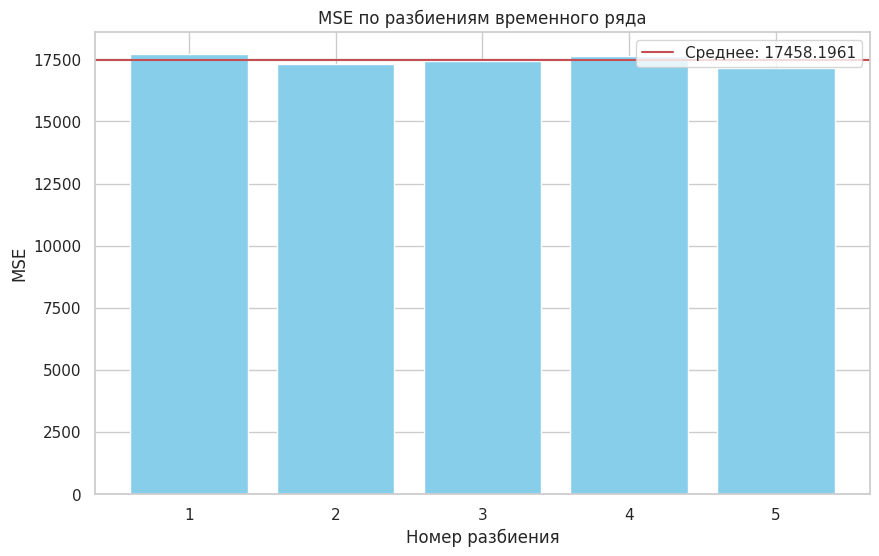

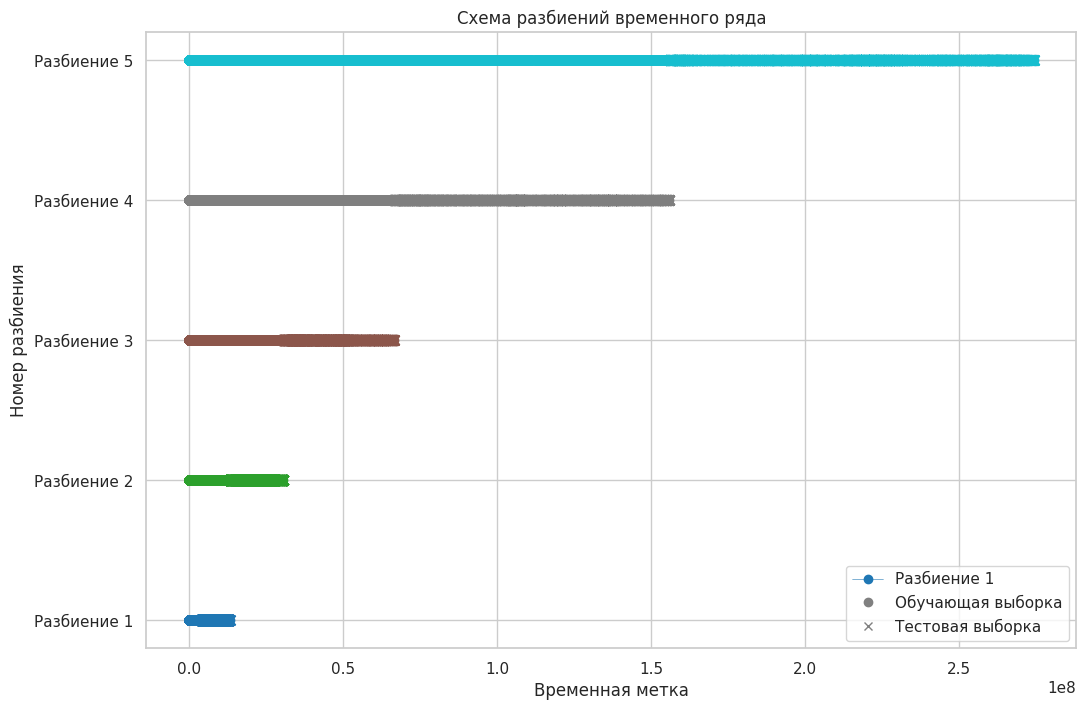

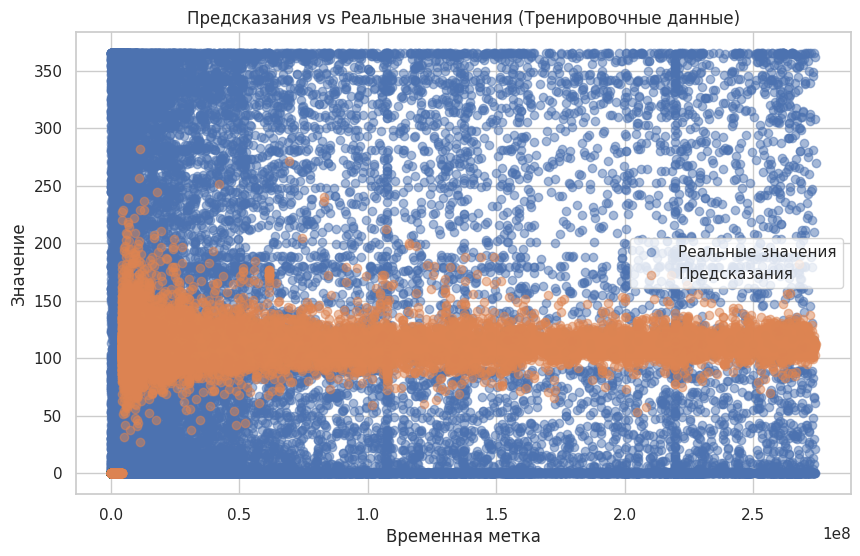

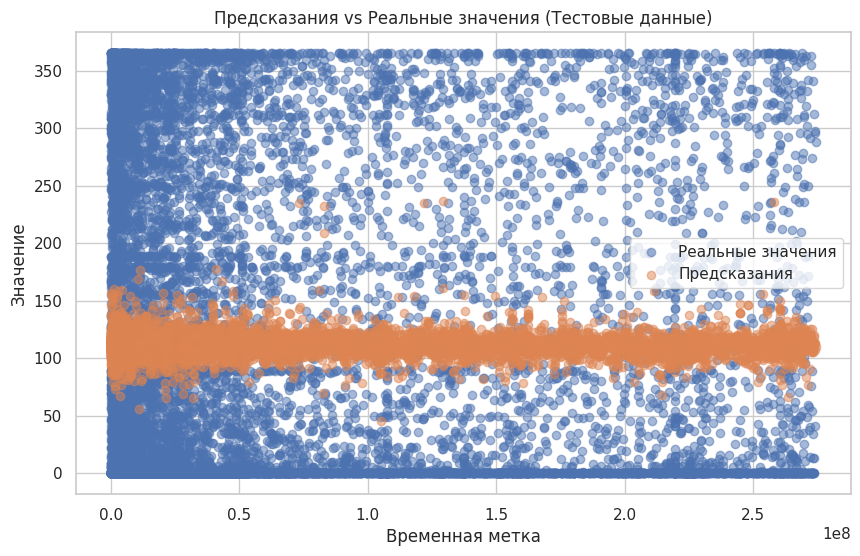

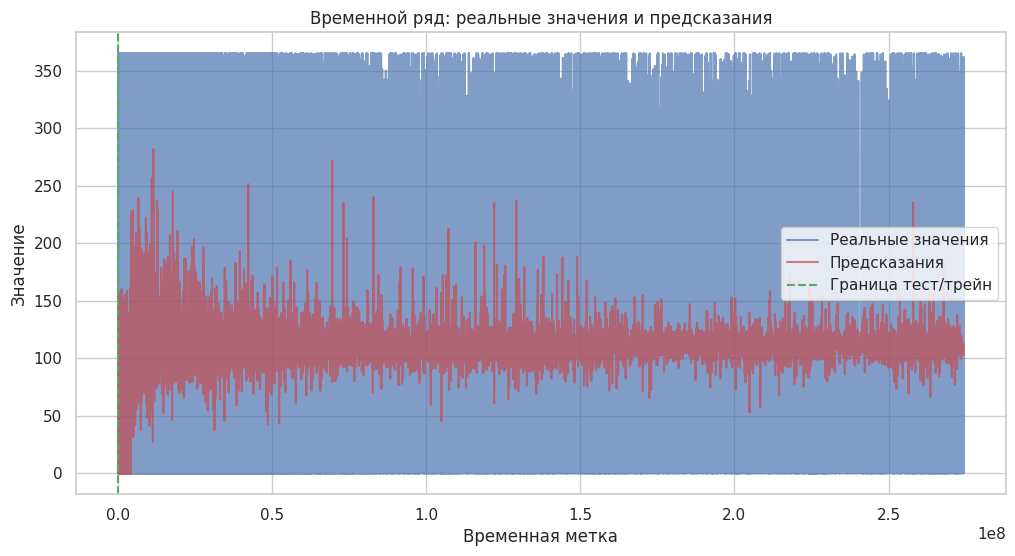

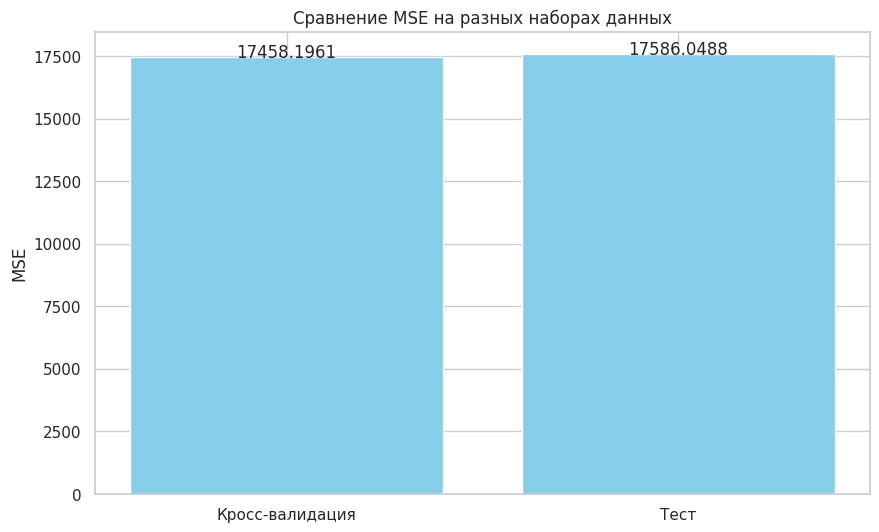

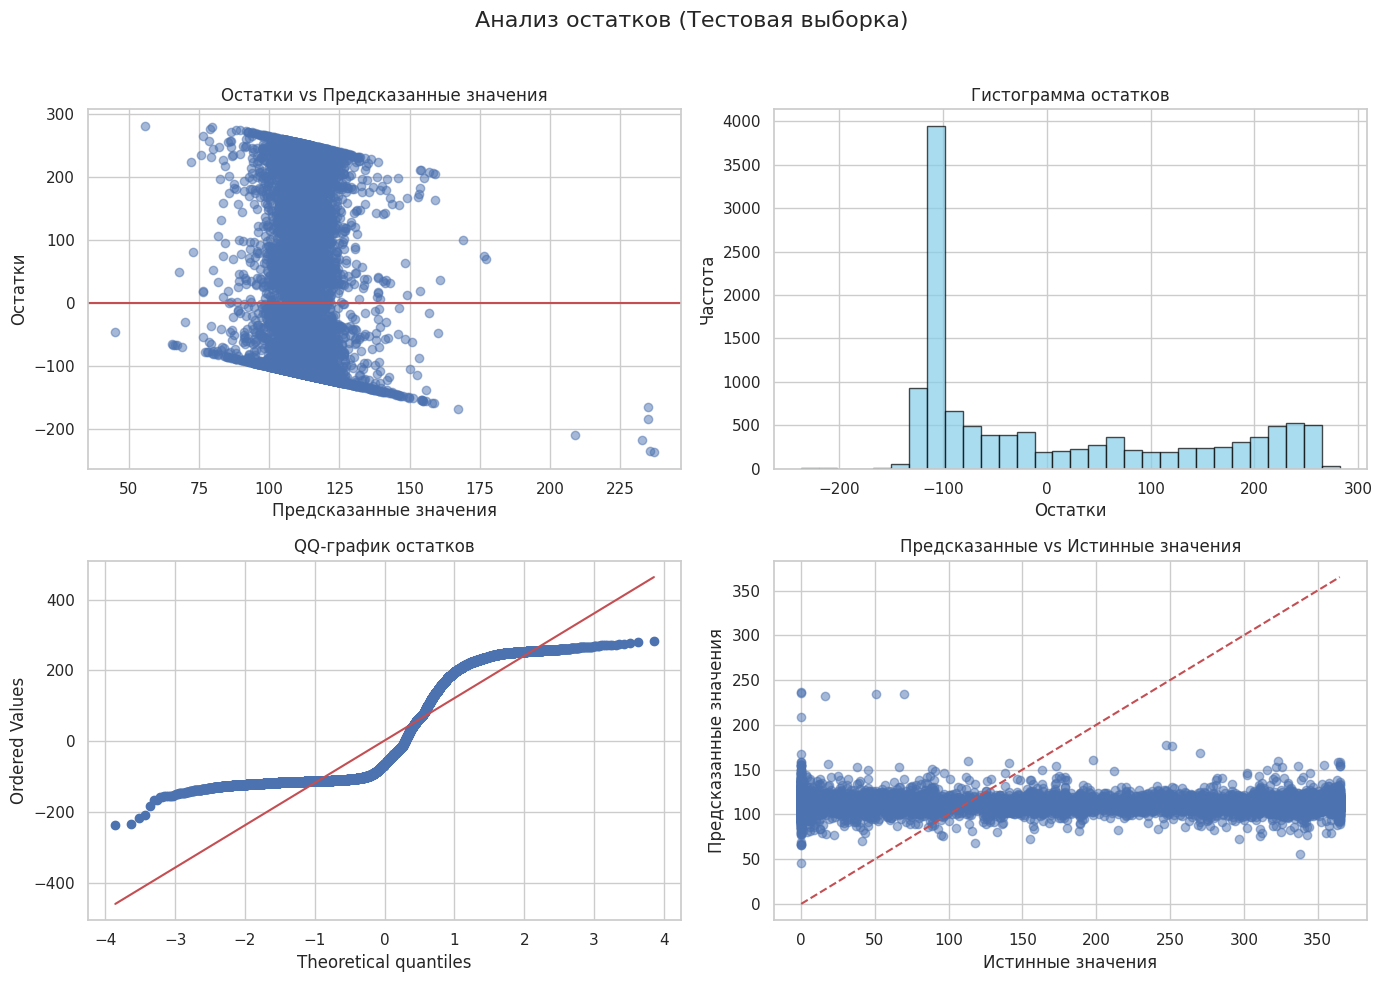

In [195]:
# Запускаем кросс-валидацию временных рядов с визуализацией
cv_results, final_model = time_series_cross_validation(
    X_train, y_train,
    X_test, y_test,
    time_col='remainder___id',  # Укажите имя столбца с временной меткой
    n_splits=5,
    gap=0,  # Промежуток между тренировочными и тестовыми данными
    model=model,
    random_state=42
)

# Метрики и подбор гиперпараметров
- metrics
- randomized grid search VS hyperopt

In [215]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score, mean_squared_error
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, cross_val_score

In [210]:
def custom_rmse_score(y_true, y_pred):
    """
    Пользовательская метрика на основе RMSE: 1 / (1 + RMSE)
    Чем выше значение, тем лучше модель
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return 1 / (1 + rmse)

def custom_mae_score(y_true, y_pred):
    """
    Пользовательская метрика на основе MAE: 1 / (1 + MAE)
    Чем выше значение, тем лучше модель
    """
    mae = mean_absolute_error(y_true, y_pred)
    return 1 / (1 + mae)

def custom_r2_adjusted(y_true, y_pred):
    """
    Скорректированный R² для регрессии
    Учитывает количество признаков для коррекции переобучения
    """
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    p = X_train.shape[1]  # количество признаков

    # Если выборка маленькая или признаков много, корректируем R²
    if n > p + 1:
        return 1 - (1 - r2) * (n - 1) / (n - p - 1)
    else:
        return r2

In [219]:
# Создаем скореры с помощью make_scorer
rmse_scorer = make_scorer(custom_rmse_score, greater_is_better=True)
mae_scorer = make_scorer(custom_mae_score, greater_is_better=True)
r2_adj_scorer = make_scorer(custom_r2_adjusted, greater_is_better=True)

In [212]:
# Создаем модель (можно заменить на любую другую регрессионную модель)
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model = model.fit(X_train, y_train)

In [213]:
y_pred = model.predict(X_test)

In [214]:
# Рассчитываем метрики
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Рассчитываем пользовательские метрики
custom_rmse = custom_rmse_score(y_test, y_pred)
custom_mae = custom_mae_score(y_test, y_pred)
custom_r2_adj = custom_r2_adjusted(y_test, y_pred)

# Выводим результаты
print(f"Стандартные метрики:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

print("\nПользовательские метрики (чем выше, тем лучше):")
print(f"Custom RMSE Score: {custom_rmse:.4f}")
print(f"Custom MAE Score: {custom_mae:.4f}")
print(f"Adjusted R²: {custom_r2_adj:.4f}")

Стандартные метрики:
RMSE: 106.6698
MAE: 83.6335
MSE: 11378.4404
R²: 0.3504

Пользовательские метрики (чем выше, тем лучше):
Custom RMSE Score: 0.0093
Custom MAE Score: 0.0118
Adjusted R²: 0.3499


In [220]:
cross_val_score(
    xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    X_train, y_train, cv=5, n_jobs=1,
    scoring=mae_scorer
)

array([0.0120518 , 0.01211852, 0.01222812, 0.01207733, 0.01207008])

In [221]:
cross_val_score(
    xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),
    X_train, y_train, cv=5, n_jobs=1,
    scoring=rmse_scorer
)

array([0.00941384, 0.00947817, 0.00951618, 0.00936503, 0.00943645])

### hyper opt VS Grid Search

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.datasets import make_regression
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from tqdm import tqdm

In [27]:
# Определяем пользовательскую метрику adjusted R2
def custom_r2_adjusted(y_true, y_pred):
    """
    Скорректированный R² для регрессии
    Учитывает количество признаков для коррекции переобучения
    """
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    p = X_train.shape[1]  # количество признаков

    # Если выборка маленькая или признаков много, корректируем R²
    if n > p + 1:
        return 1 - (1 - r2) * (n - 1) / (n - p - 1)
    else:
        return r2

# Создаем скорер для использования в RandomizedSearchCV
custom_r2_adj_scorer = make_scorer(custom_r2_adjusted, greater_is_better=True)

In [28]:
# TODO: подумать над кастом метрикой для оптимизации поиска гиперпараметров

In [30]:
# Функция для расчета всех метрик
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    r2_adj = custom_r2_adjusted(y_true, y_pred)

    return {
        'RMSE': rmse,
        'MAE': mae,
        'MSE': mse,
        'R2': r2,
        'R2_Adjusted': r2_adj
    }

In [232]:
# Определяем общие параметры для обоих методов
param_space = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4, 0.5],
}

In [233]:
# Создаем класс для отслеживания прогресса RandomizedSearchCV с tqdm
class TqdmCallback:
    def __init__(self, total):
        self.pbar = tqdm(total=total, desc="RandomizedSearchCV")
        self.n_completed = 0

    def __call__(self, *args, **kwargs):
        self.n_completed += 1
        self.pbar.update(1)

    def close(self):
        self.pbar.close()

In [247]:
start_time_random = time.time()

# Инициализируем модель XGBRegressor
xgb_model = xgb.XGBRegressor(random_state=42)

# Настраиваем RandomizedSearchCV
n_iter_random = 15
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_space,
    n_iter=n_iter_random,
    scoring=custom_r2_adj_scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

# Создаем callback для отслеживания прогресса
callback = TqdmCallback(n_iter_random)

# Обучаем модель с RandomizedSearchCV
try:
    random_search.fit(X_train, y_train)
finally:
    callback.close()

# Получаем лучшие параметры и время выполнения
best_params_random = random_search.best_params_
best_score_random = random_search.best_score_
time_random = time.time() - start_time_random

# Обучаем модель с лучшими параметрами
best_model_random = xgb.XGBRegressor(**best_params_random, random_state=42)
best_model_random.fit(X_train, y_train)

# Оцениваем модель на тестовых данных
y_test_pred_random = best_model_random.predict(X_test)
metrics_random = calculate_metrics(y_test, y_test_pred_random)

print(f"\nRandomizedSearchCV завершен за {time_random:.2f} секунд")
print(f"Лучшие параметры: {best_params_random}")
print(f"Лучший CV score: {best_score_random:.4f}")
print(f"Метрики на тестовых данных:")
for metric, value in metrics_random.items():
    print(f"  {metric}: {value:.4f}")

RandomizedSearchCV:   0%|          | 0/15 [00:35<?, ?it/s]



RandomizedSearchCV завершен за 35.44 секунд
Лучшие параметры: {'subsample': 0.8, 'n_estimators': 150, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.4, 'colsample_bytree': 0.9}
Лучший CV score: 0.3965
Метрики на тестовых данных:
  RMSE: 102.9731
  MAE: 78.4579
  MSE: 10603.4561
  R2: 0.3947
  R2_Adjusted: 0.3941


In [ ]:
# NOTE: Подбор гиперпараметров не может дать значительный прирост метрике
# Как правило это до 5%
# А новые данные могут дать +20% в среднем (feature engineering)

In [ ]:
# MSE: 10603.4561
# MSE: 10686.9639
# calculate_metrics

In [ ]:
# TODO: а вообще то таргет надо привести к нормальному распределению
# plt.hist(np.log1p(train['target']))

In [246]:
# 2. Метод Hyperopt
print("\nЗапуск Hyperopt...")
start_time_hyperopt = time.time()

# Определяем пространство поиска для Hyperopt с использованием hp.quniform для числовых параметров
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 200, 50),  # от 50 до 200 с шагом 50
    'max_depth': hp.quniform('max_depth', 3, 7, 1),  # от 3 до 7 с шагом 1
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),  # от 0.01 до 0.2
    'subsample': hp.uniform('subsample', 0.6, 1.0),  # от 0.6 до 1.0
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),  # от 0.6 до 1.0
    'min_child_weight': hp.quniform('min_child_weight', 1, 7, 2),  # от 1 до 7 с шагом 2
    'gamma': hp.uniform('gamma', 0, 0.4)  # от 0 до 0.4
}

# Определяем целевую функцию для Hyperopt
def objective(params):
    # Преобразуем параметры в целые числа, где это необходимо
    model_params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': params['learning_rate'],
        'subsample': params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
        'min_child_weight': int(params['min_child_weight']),
        'gamma': params['gamma'],
        'random_state': 42
    }

    # Создаем модель с текущими параметрами
    model = xgb.XGBRegressor(**model_params)

    # Выполняем кросс-валидацию
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring=custom_r2_adj_scorer, n_jobs=-1)

    # Обновляем прогресс-бар
    hyperopt_pbar.update(1)

    # Возвращаем отрицательное среднее значение (так как Hyperopt минимизирует)
    return {'loss': -np.mean(scores), 'status': STATUS_OK, 'params': model_params}

# Создаем прогресс-бар для Hyperopt
n_iter_hyperopt = 30
hyperopt_pbar = tqdm(total=n_iter_hyperopt, desc="Hyperopt")

# Запускаем оптимизацию Hyperopt
trials = Trials()
best_hyperopt = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=n_iter_hyperopt,
    trials=trials,
    verbose=0
)

# Закрываем прогресс-бар
hyperopt_pbar.close()

# Получаем лучшие параметры
best_trial_idx = np.argmin([t['result']['loss'] for t in trials.trials])
best_params_hyperopt = trials.trials[best_trial_idx]['result']['params']

# Получаем лучший score и время выполнения
best_score_hyperopt = -min([t['result']['loss'] for t in trials.trials])
time_hyperopt = time.time() - start_time_hyperopt

# Обучаем модель с лучшими параметрами
best_model_hyperopt = xgb.XGBRegressor(**best_params_hyperopt)
best_model_hyperopt.fit(X_train, y_train)

# Оцениваем модель на тестовых данных
y_test_pred_hyperopt = best_model_hyperopt.predict(X_test)
metrics_hyperopt = calculate_metrics(y_test, y_test_pred_hyperopt)

print(f"\nHyperopt завершен за {time_hyperopt:.2f} секунд")
print(f"Лучшие параметры: {best_params_hyperopt}")
print(f"Лучший CV score: {best_score_hyperopt:.4f}")
print(f"Метрики на тестовых данных:")
for metric, value in metrics_hyperopt.items():
    print(f"  {metric}: {value:.4f}")


Запуск Hyperopt...


Hyperopt: 100%|██████████| 30/30 [01:27<00:00,  2.91s/it]



Hyperopt завершен за 87.23 секунд
Лучшие параметры: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.0902970045848882, 'subsample': 0.7515754664087764, 'colsample_bytree': 0.9634752735928804, 'min_child_weight': 4, 'gamma': 0.22807722271557213, 'random_state': 42}
Лучший CV score: 0.3941
Метрики на тестовых данных:
  RMSE: 103.3778
  MAE: 78.3931
  MSE: 10686.9639
  R2: 0.3899
  R2_Adjusted: 0.3894


### Время работы моделей
(для real time / near real time)

In [ ]:
# NOTE
# fit
# predict
# 1000 trees > 100 trees
# model inference time
# требование: модель predict < 50ms

In [248]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import lightgbm as lgb
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [257]:
# Список конфигураций моделей для тестирования
model_configs = [
    {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1},
    {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05},
    {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05},
    {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05},
    {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.01},
    {'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.005}
]

In [258]:
# Списки для хранения результатов
mse_scores = []
prediction_times = []
model_names = []

In [259]:
# Обучаем модели и измеряем производительность
for i, config in enumerate(model_configs):
    print(f"Training model with config: {config}")

    # Создаем и обучаем модель
    model = lgb.LGBMRegressor(**config, random_state=42, verbose=0)
    model.fit(X_train, y_train)

    # Измеряем время предсказания
    start_time = time.time()
    n_repeats = 100  # Повторяем предсказание несколько раз для более точного измерения
    for _ in range(n_repeats):
        y_pred = model.predict(X_test)
    end_time = time.time()

    # Вычисляем среднее время предсказания в миллисекундах
    prediction_time = (end_time - start_time) * 1000 / n_repeats

    # Вычисляем MSE
    mse = mean_squared_error(y_test, y_pred)

    # Сохраняем результаты
    mse_scores.append(mse)
    prediction_times.append(prediction_time)
    model_names.append(f"Model {i+1}")

    print(f"  MSE: {mse:.2f}")
    print(f"  Prediction time: {prediction_time:.2f} ms")
    print()

Training model with config: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1}
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

In [260]:
# Создаем DataFrame с результатами
results_df = pd.DataFrame({
    'Model': model_names,
    'Config': [str(config) for config in model_configs],
    'MSE': mse_scores,
    'Prediction Time (ms)': prediction_times
})

print("Results summary:")
print(results_df)

Results summary:
     Model                                             Config           MSE  \
0  Model 1  {'n_estimators': 50, 'max_depth': 3, 'learning...  11707.026869   
1  Model 2  {'n_estimators': 100, 'max_depth': 5, 'learnin...  11089.605073   
2  Model 3  {'n_estimators': 200, 'max_depth': 5, 'learnin...  10857.419530   
3  Model 4  {'n_estimators': 300, 'max_depth': 5, 'learnin...  10786.392837   
4  Model 5  {'n_estimators': 500, 'max_depth': 7, 'learnin...  10996.739540   
5  Model 6  {'n_estimators': 1000, 'max_depth': 10, 'learn...  10968.359440   

   Prediction Time (ms)  
0             24.776070  
1             83.414218  
2            157.826257  
3            237.959530  
4            479.871213  
5           1405.071981  


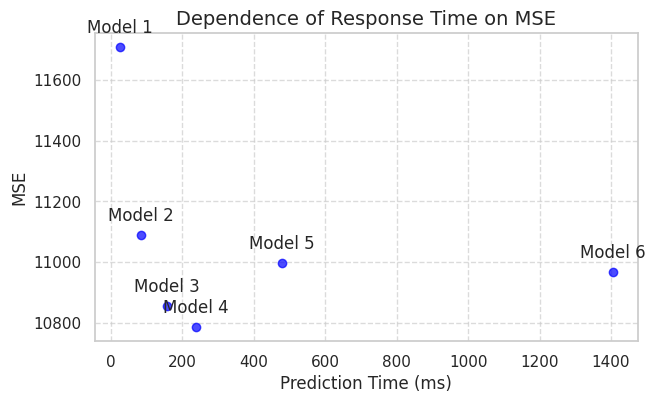

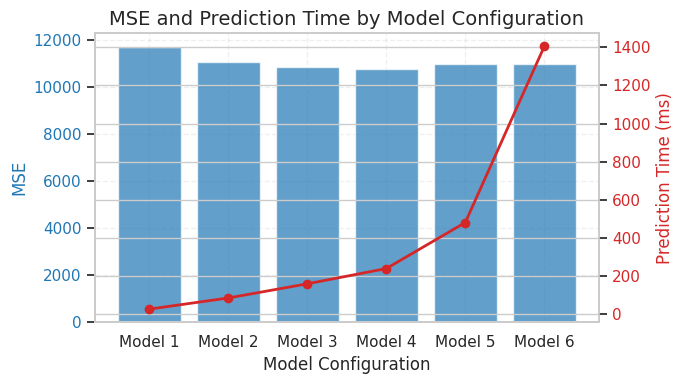

In [261]:
# Визуализация зависимости времени отклика от MSE
plt.figure(figsize=(7, 4))
plt.scatter(prediction_times, mse_scores, color='blue', alpha=0.7)

# Добавляем подписи для каждой точки
for i, model in enumerate(model_names):
    plt.annotate(model,
                 (prediction_times[i], mse_scores[i]),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center')

plt.grid(True, linestyle='--', alpha=0.7)
plt.title('Dependence of Response Time on MSE', fontsize=14)
plt.xlabel('Prediction Time (ms)', fontsize=12)
plt.ylabel('MSE', fontsize=12)

# Сохраняем график
plt.savefig('response_time_vs_mse.png', dpi=300, bbox_inches='tight')
plt.show()

# Дополнительно: создаем график с двумя осями Y для лучшей визуализации
fig, ax1 = plt.subplots(figsize=(7, 4))

# Сортируем данные по времени предсказания
sorted_indices = np.argsort(prediction_times)
sorted_times = [prediction_times[i] for i in sorted_indices]
sorted_mse = [mse_scores[i] for i in sorted_indices]
sorted_names = [model_names[i] for i in sorted_indices]

# Первая ось Y для MSE
color = 'tab:blue'
ax1.set_xlabel('Model Configuration', fontsize=12)
ax1.set_ylabel('MSE', color=color, fontsize=12)
ax1.bar(sorted_names, sorted_mse, color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)

# Вторая ось Y для времени предсказания
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Prediction Time (ms)', color=color, fontsize=12)
ax2.plot(sorted_names, sorted_times, color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# Добавляем заголовок и сетку
plt.title('MSE and Prediction Time by Model Configuration', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.3)

fig.tight_layout()
# plt.savefig('mse_and_time_by_model.png', dpi=300, bbox_inches='tight')
plt.show()

## auto ML
- open source VS self made
- https://github.com/sb-ai-lab/LightAutoML
  - tabular DL (TabDL)
  - nlp
  - classification / regression

In [ ]:
# TODO: проверить auto ML на задаче соревнования

In [2]:
%autosave 60

Autosaving every 60 seconds


In [3]:
%pip install -U -q catboost

In [4]:
%pip install -U -q lightautoml

In [12]:
path_files = 'drive/MyDrive/ШАД 2025/'
train = pd.read_csv(path_files + 'train_2.csv')

train.drop(['_id', 'last_dt', 'name', 'host_name'], axis=1, inplace=True)
cat_columns = ['location_cluster', 'location', 'type_house']

X_train, X_test = train_test_split(
    train,
    test_size=0.33,
    random_state=42,
    stratify=train['target'],
)

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', oe, cat_columns)
    ], remainder='passthrough'
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [14]:
from lightautoml.automl.presets.tabular_presets import TabularAutoML
from lightautoml.tasks import Task

/usr/local/lib/python3.11/dist-packages/lightautoml/transformers/text.py:22: UserWarning: 'gensim' - package isn't installed
  warnings.warn("'gensim' - package isn't installed")


In [20]:
automl = TabularAutoML(task = Task(name='reg', metric='mse'), timeout=180)

In [21]:
oof_preds = automl.fit_predict(X_train, roles = {'target': 'remainder__target'}).data

INFO:lightautoml.automl.presets.base:Stdout logging level is ERROR.
INFO:lightautoml.automl.presets.base:Task: reg

INFO:lightautoml.automl.presets.base:Start automl preset with listed constraints:
INFO:lightautoml.automl.presets.base:- time: 180.00 seconds
INFO:lightautoml.automl.presets.base:- CPU: 4 cores
INFO:lightautoml.automl.presets.base:- memory: 16 GB

INFO:lightautoml.reader.base:Train data shape: (24569, 11)

INFO3:lightautoml.reader.base:Feats was rejected during automatic roles guess: []
INFO:lightautoml.automl.base:Layer 1 train process start. Time left 168.69 secs
INFO:lightautoml.ml_algo.base:Start fitting Lvl_0_Pipe_0_Mod_0_LinearL2 ...
DEBUG:lightautoml.ml_algo.base:Training params: {'tol': 1e-06, 'max_iter': 100, 'cs': [1e-05, 5e-05, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000], 'early_stopping': 2, 'categorical_idx': [0, 2, 3], 'embed_sizes': array([ 6, 11, 11], dtype=int32), 'data_size': 24}
INFO2:lig

In [ ]:
print(1)

In [ ]:
# TODO: target encoder лучше чем OrdinalEncoder
# TODO: определить на чьей стороне ты - optuna vs hyperopt

In [22]:
test_preds = automl.predict(X_test).data

In [23]:
test_preds

array([[317.15942],
       [255.30322],
       [314.7278 ],
       ...,
       [159.17989],
       [186.03175],
       [ 82.58545]], dtype=float32)

In [ ]:
# MSE: 10603.4561
# MSE: 10686.9639
# TODO: дать automl больше времени

In [32]:
calculate_metrics(X_test['remainder__target'].values, test_preds, )

{'RMSE': 104.34357217714707,
 'MAE': 79.92444610595703,
 'MSE': 10887.5810546875,
 'R2': 0.3701328635215759,
 'R2_Adjusted': 0.3695597834139446}

### self made auto ml

In [ ]:
# NOTE:
# ансамбли моделей
#     стекинг
# подбор
#     гиперпараметров
#     метрик
#     функций оптимизации
# отбор признаков
# оценка
#     валидация модели